In [1]:
# Copyright 2026 Province of British Columbia

#Script was translated from BC Stats 07-single-db-centroid-assignment.R file. 
# Found in GitHub repo: https://github.com/bcgov/bcstats-govt-service-locations/blob/main/R/07-single-db-centroid-assignment.R

# =========================================================================== #
# Self-contained Dissemination Block (DB) centroid assignment script

# This script performs a quick analysis by assigning each DB to the
# nearest Service BC (SBC) facility using simple centroid proximity. It then allocate
# population projections to DBs, rolls them up to facilities, and writes 2 CSVs plus
# a facility catchment shapefile.
#
# Inputs:
#   1) A CSV containing SBC facility names and latitude/longitude columns (EPSG:4326)
#   2) DB shapefiles from the BC Data Catalogue (downloaded automatically)
#   3) BC population projections from the BC Data Catalogue (downloaded automatically)
#   4) Census population data from Cancensus (downloaded automatically; requires API key)
#      Steps to Obtain Your API Key:
#      Visit the CensusMapper website: Go to the CensusMapper sign-up page.
#      Create an account: Register for a free account.
#      Access your profile: Once signed in, navigate to the "Edit Profile" section.
#      Retrieve the key: Your API key will be displayed there.
#      Once you have your key, you can store it in your system environment so it
#      is automatically used in API calls.
#      In R (using the cancensus package): The recommended way to set the key permanently
#      is by using the set_cancensus_api_key() function in R with your actual key:
#      cancensus::set_cancensus_api_key("YOUR_KEY_HERE", install = TRUE)
#      The script can then use Sys.getenv("CM_API_KEY")
#    5) CSD rural/urban identification from Rural Initiatives Excel matrix

# Outputs (written to a user-specified directory that will be created if missing):
#   - CSV 1 (DB assignments list - which DB gets assigned to which SBC facility using the centroid only method):
#            dbid | csdid | csd_name | pop_2025 | pop_2030 | pop_2035 |
#            assigned_facility | centroid_distance_m | urban_rural
#   - CSV 2 (SBC facility population projections - once every DB is rolled up into its assigned SBC facility,
#            what are the associated population demographics?):
#            facility | pop_2025 | pop_2030 | pop_2035 |
#            est_population_0_to_14_yrs | est_population_15_to_24_yrs |
#            est_population_25_to_64_yrs | est_population_over_64_years |
#            median_age | mean_age
#   - Shapefile: SBC-facility-level polygons representing aggregated DB catchments
#
# Facility CSV requirements:
#   - One row per facility
#   - Must contain exactly these columns:
#       - 'nearest_facility': (facility name)
#       - 'coord_x': (longitude, EPSG:4326)
#       - 'coord_y': (latitude, EPSG:4326)
#
# Notes/limitations:
#   - Assignment uses centroid distance in BC Albers (EPSG:3005), not road travel distance/time.
#   - Urban/rural is joined from the Rural Initiatives Excel matrix at the CSD level
#     ("Census Subdivision Data" sheet, "Rural Category" field). This script does not
#     compute urban/rural from DB density or StatCan population centres.


In [13]:
# =============================================================================
# Install required packages
# =============================================================================
!python -m pip install --trusted-host pypi.org \
  --trusted-host pypi.python.org \
  --trusted-host files.pythonhosted.org \
bcdata

In [14]:
!python -m pip install --trusted-host pypi.org \
  --trusted-host pypi.python.org \
  --trusted-host files.pythonhosted.org \
pycancensus

In [15]:
# =============================================================================
# Required packages
# =============================================================================
import os
import re
from io import BytesIO
import time

import requests
import pandas as pd
import geopandas as gpd
import shapely.geometry #import Point
import matplotlib.pyplot as plt

import bcdata
import pycancensus as pc


In [16]:
# =============================================================================
# Set API Key for CanCensus
# need to add instruction 
# =============================================================================

os.environ["CANCENSUS_API_KEY"] = "CensusMapper_652da0724950c3f93142d3e82ecc56fd"

In [34]:
# =============================================================================
# Parameters
# =============================================================================

CURRENT_YEAR = 2025
PROJECTION_YEARS = [CURRENT_YEAR, CURRENT_YEAR + 5, CURRENT_YEAR + 10]
CANCENSUS_YEAR = "CA21"

#File locations for input/output

from pathlib import Path

BASE_DIR = Path.cwd()
INPUT_DIR = BASE_DIR / "input"
OUTPUT_DIR = BASE_DIR / "output"

#FACILITIES_CSV = INPUT_DIR / "full-service-bc-locs-wgs84.csv"
FACILITIES_CSV = INPUT_DIR / "full-service-bc-locs-wgs84_updated.xls"
SEHI_CSV=INPUT_DIR / "SEHI-csd-weighted-scores-2025-07-21_masked_ind25.xls"


RURAL_MATRIX_XLSX = INPUT_DIR / "rural_matrix_list_of_communities.xlsx"
OUTPUT_DIRECTORY = OUTPUT_DIR

# file_path = "your file path here. May or may not work with network drives. Tested locally(ish) on onedrive."
# FACILITIES_CSV = f"{file_path}/data/test/full-service-bc-locs-wgs84.csv"
# RURAL_MATRIX_XLSX = f"{file_path}/data/test/rural_matrix_list_of_communities.xlsx"
# OUTPUT_DIRECTORY = f"{file_path}/outputs/test_py_output"

# BCDC keys for DB and CSD census data
DB_LAYER_KEY = "76909e49-8ba8-44b1-b69e-dba1fe9ecfba"  
CSD_LAYER_KEY = "WHSE_HUMAN_CULTURAL_ECONOMIC.CEN_CENSUS_SUBDIVSIONS_SVW"

# Pop projections: CKAN package + resource IDs from R script
POP_PROJ_PACKAGE_ID = "86839277-986a-4a29-9f70-fa9b1166f6cb"
POP_PROJ_RESOURCE_ID = "0e15d04d-127c-457a-b999-20800c929927"

# Census area
PR = "59"

# Census vectors:
# Currently not in use as they crash the api
CENSUS_VECTORS = ["v_CA21_1"]


# Helper Functions: 

In [18]:
# =============================================================================
# Helper functions
# =============================================================================

# -----------------------------------------------------------------------
# Function: assign_dbs
#
# Description: Assigns each dissemination block (DB) directly to the
# nearest Service BC facility location based on centroid distance. Mirrors the R assign_dbs() behavior.
#
# Inputs:
#   - db_shapefile: A GeoDataFrame object containing all DB geometries with `dbid` column
#   - assigned_facility: Data frame with columns `dbid` and `assigned`
#   - facility_locations: A GeoDataFrame object containing Service BC facility locations (EPSG:3005)
#   - verbose: Whether to print progress messages (default TRUE)
#
# Outputs:
#   - Returns an updated data frame with DB assignments
#
# Assumptions:
#   - db_shapefile must be A GeoDataFrame object with spatial geometries
#   - facility_locations must be A GeoDataFrame object with point geometries and a
#     'nearest_facility' column identifying each location
# ------------------------------------------------------------------------

def assign_dbs(db_gdf: gpd.GeoDataFrame,
               assigned_facility: pd.DataFrame,
               facility_locations: gpd.GeoDataFrame,
               verbose: bool = True) -> pd.DataFrame:

    # Join existing assignments
    db = db_gdf.merge(assigned_facility, on="dbid", how="left")

    unassigned = db[db["assigned"].isna()].copy()
    if unassigned.shape[0] == 0:
        if verbose:
            print("No unassigned DBs found.")
        return assigned_facility.copy()

    if facility_locations.shape[0] == 0:
        raise ValueError("No facility locations provided.")

    # Ensure unique facilities
    facilities = facility_locations.drop_duplicates(subset=["nearest_facility"]).copy()

    if verbose:
        print(f"Processing {len(unassigned)}:, unassigned DBs")
        print(f"Finding nearest facility among {len(facilities)}:, locations")

    # Ensure consistent CRS 
    if unassigned.crs != facilities.crs:
        if verbose:
            print("Transforming geometries to ensure consistent CRS...")
        facilities = facilities.to_crs(unassigned.crs)

    # Centroids
    if verbose:
        print("Calculating centroids for unassigned DBs...")
    unassigned_centroids = unassigned.copy()
    unassigned_centroids["geometry"] = unassigned_centroids.geometry.centroid

    # Nearest join (GeoPandas sjoin_nearest if available)
    try:
        joined = gpd.sjoin_nearest(
            unassigned_centroids[["dbid", "geometry"]],
            facilities[["nearest_facility", "geometry"]],
            how="left",
            distance_col="min_distance"
        )
        new_assignments = pd.DataFrame({
            "dbid": joined["dbid"].astype(str),
            "assigned": joined["nearest_facility"].astype(str),
            "assignment_method": "nearest_facility",
            "min_distance": joined["min_distance"].astype(float)
        })
    except Exception as e:
        # Fallback: brute force
        if verbose:
            print("sjoin_nearest unavailable; falling back to brute-force distance. Reason:", e)

        fac_geom = facilities.set_index("nearest_facility").geometry
        fac_names = fac_geom.index.to_list()

        rows = []
        for dbid, geom in zip(unassigned_centroids["dbid"], unassigned_centroids.geometry):
            dists = fac_geom.distance(geom)
            idx = int(dists.values.argmin())
            rows.append((str(dbid), str(fac_names[idx]), "nearest_facility", float(dists.iloc[idx])))

        new_assignments = pd.DataFrame(rows, columns=["dbid", "assigned", "assignment_method", "min_distance"])

    # Combine with existing assignments
    if assigned_facility is None or assigned_facility.empty:
        complete = new_assignments.copy()
    else:
        base = assigned_facility.copy()
        base["assignment_method"] = "drive_time"
        base["min_distance"] = float("nan")
        complete = pd.concat([base, new_assignments], ignore_index=True)

    return complete


# -----------------------------------------------------------------------
# Function: clean_names
#
# Description: Rough equivalent of janitor::clean_names()
#   Lowercase, replace non-alphanum with _, collapse repeats, strip edges
#
# Inputs:
#   - cols: A list of column names
#
# Outputs:
#   - Returns an updated list with cleaned column names
# ------------------------------------------------------------------------

def clean_names(cols):

    out = []
    for c in cols:
        c2 = str(c).strip().lower()
        c2 = re.sub(r"[^a-z0-9]+", "_", c2)
        c2 = re.sub(r"_+", "_", c2).strip("_")
        out.append(c2)
    return out


# -----------------------------------------------------------------------
# Function: ensure_dir
#
# Description: A quick file check to ensure folder directory path exists. 
#              Partial replacement for R safepaths library
# ------------------------------------------------------------------------

def ensure_dir(path):
    os.makedirs(path, exist_ok=True)

# -----------------------------------------------------------------------
# Function: download_bcdc_resource
#
# Description: Download a BC Data Catalogue resource via CKAN API and read it into a DataFrame.
#              Works well for CSV/Excel resources with a direct download URL.
#
# Inputs:
#   - package_id: dataset/package id
#   - resource_id: resource id
#
# Outputs:
#   - Returns a pandas dataframe
# ------------------------------------------------------------------------

def download_bcdc_resource(package_id: str, resource_id: str) -> pd.DataFrame:

    # API endpoint
    base = "https://catalogue.data.gov.bc.ca/api/3/action"

    # Pull package metadata to find the resource URL
    pkg = requests.get(f"{base}/package_show", params={"id": package_id}, timeout=120)
    pkg.raise_for_status()
    pkg_json = pkg.json()
    if not pkg_json.get("success"):
        raise RuntimeError(f"package_show failed for {package_id}: {pkg_json}")

    resources = pkg_json["result"].get("resources", [])
    res = next((r for r in resources if r.get("id") == resource_id), None)
    if res is None:
        raise ValueError(f"Resource {resource_id} not found in package {package_id}")

    url = res.get("url")
    if not url:
        raise ValueError(f"No URL found for resource {resource_id}")

    # Download
    r = requests.get(url, timeout=300)
    r.raise_for_status()

    # Try read by format / extension
    fmt = (res.get("format") or "").lower()
    #name = (res.get("name") or "").lower()
    if "csv" in fmt or url.lower().endswith(".csv"):
        return pd.read_csv(BytesIO(r.content))
    if "xlsx" in fmt or url.lower().endswith(".xlsx"):
        return pd.read_excel(BytesIO(r.content))
    if "xls" in fmt or url.lower().endswith(".xls"):
        return pd.read_excel(BytesIO(r.content))

    # Fallback: attempt CSV
    return pd.read_csv(BytesIO(r.content))

# -----------------------------------------------------------------------
# Function: download_bcdc_resource
#
# Description: Fetch WFS (web feature service) geodata via BCdata package and return a GeoDataFrame
#              bcdata.get_data supports returning a GeoDataFrame when as_gdf=True
#
# Inputs:
#   - layer_key: In theory can be a catalogue slug/package name or object name; some UUIDs may also work
#                Currently uses DB_LAYER_KEY and CSD_LAYER_KEY parameters set below
#   - query: optional query to format search
#   - crs: optional ESPG geodetic parameter (coordinate reference system)
#
# Outputs:
#   - Returns a geodataframe
# ------------------------------------------------------------------------

def get_wfs_geodata(layer_key: str, query: str = None, crs=None) -> gpd.GeoDataFrame:

    gdf = bcdata.get_data(layer_key, query=query, as_gdf=True)
    if not isinstance(gdf, gpd.GeoDataFrame):
        raise TypeError(f"Expected GeoDataFrame from bcdata.get_data(as_gdf=True), got {type(gdf)}")
    if crs is not None:
        gdf = gdf.to_crs(crs)
    return gdf

# -----------------------------------------------------------------------
# Function: weighted_median
#
# Description: Compute weighted median of values with non-negative weights.
#              Used to calculated weighted_ages
#
# Inputs:
#   - values: The input on which to calculate weights
#   - weights: the weighting parameters
#
# Outputs:
#   - Returns a decimal value
# ------------------------------------------------------------------------

def weighted_median(values, weights):
    """
    Compute weighted median of values with non-negative weights.
    """
    s = pd.DataFrame({"v": values, "w": weights}).dropna()
    s = s[s["w"] > 0].sort_values("v")
    if s.empty:
        return float("nan")
    csum = s["w"].cumsum()
    cutoff = s["w"].sum() / 2.0
    return float(s.loc[csum >= cutoff, "v"].iloc[0])

# -----------------------------------------------------------------------
# Function: get_db_population_bc
#
# Description: Download Dissemination Block population data for all of BC using the pycancensus package.
#              Uses chunking.  Function is a fallback to the initial request in the script below, which uses no chunking.
#                   - First tries DB by Census subdivision.
#                   - If a CSD DB request fails, falls back to DB by Dissemination area within that CSD.
#
# Inputs:
#   - dataset: The input on which to calculate weights
#   - pr: the area to use. Typically 59 which is BC. Set in the parameters section
#   - vector: Additional parameters to control what level of census data to pull. 
#             Keeping this greyed out as is seems to crash the api with too large of a request.
#   - sleep_s: time ti sleep between chunks
#   - fallback_sleep_s: time to sleep between chunks during fallback
#   - quiet: show terminal output from api or not
#   - use_cache: cahce data to reduce multiple api request size 
#
# Outputs:
#   - out: returns a pandas dataframe with the cnesus population data by DB
#   - failures: returns a list of CSDs that were unsuccessful and went to the fallback method for DAs 
#
# Assumptions:
#   - assumes that a cancensus api key is available on the path
#   - if fallback to DA chunking triggers, assumes that no duplication in DBs will occur in dataset.
#   - If weirdness if observed can add a uniqueness check later.
# ------------------------------------------------------------------------

def get_db_population_bc(
    dataset,
    pr,
    vector,
    sleep_s=0.2,
    fallback_sleep_s=0.2,
    quiet=False,
    use_cache=True
):
    """
    Download DB-level population for all of BC by chunking requests.
    - First tries DB by CSD (municipality).
    - If a CSD DB request fails, falls back to DB by DA within that CSD.
    Returns a concatenated DataFrame.
    """

    #Find BC CSD region identifiers
    regions_df = pc.get_census(
                dataset=dataset,
                regions={"PR": pr},
                level="CSD",                 
                geo_format=None,
                quiet=quiet,
                use_cache=use_cache
            )
    bc_csds = regions_df['GeoUID']
    print("census subdivisions", bc_csds)
    
    chunks = []
    failures = []

    #Go through chunks to get DBs in each CSD for BC
    for i, csd in enumerate(bc_csds, start=1):
        if not quiet:
            print(f"[{i}/{len(bc_csds)}] CSD={csd} -> DB")

        try:
            #Try DB directly for the CSD
            print("Trying: ",csd)
            df = pc.get_census(
                dataset=dataset,
                regions={"CSD": csd},
                #vectors=[vector],
                level="DB",                 
                geo_format=None,
                quiet=quiet,
                use_cache=use_cache
            )
            if len(df):
                chunks.append(df)

        except Exception as e:
            #Fall back: get DAs for that CSD, then DB per DA
            failures.append((csd, str(e)))
            if not quiet:
                print(f"  -> {csd} DB failed ({e}); falling back to DA->DB")

            # Get all DAs within this CSD
            da_df = pc.get_census(
                dataset=dataset,
                regions={"CSD": csd},
                #vectors=[vector],           
                level="DA",
                geo_format=None,
                quiet=quiet,
                use_cache=use_cache
            )

            # Get GeoUID for DAs in CSD 
            da_ids = da_df["GeoUID"].astype(str).tolist()
            print(da_ids)
            
            #now get DB for DAs in CSD
            for da in da_ids:
                try:
                    db_df = pc.get_census(
                        dataset=dataset,
                        regions={"DA": da},
                        #vectors=[vector],
                        level="DB",
                        geo_format=None,
                        quiet=True,
                        use_cache=use_cache
                    )
                    if len(db_df):
                        chunks.append(db_df)
                except Exception as e2:
                    if not quiet:
                        print(f"    -> DA {da} DB failed: {e2}")
                time.sleep(fallback_sleep_s)

        time.sleep(sleep_s)

    out = pd.concat(chunks, ignore_index=True) if chunks else pd.DataFrame()
    return out, failures




# Summary Function 

In [19]:
# =============================================================================
# Helper functions
# =============================================================================


# -----------------------------------------------------------------------
# Function: summarize_accessibility_from_csv
#
# Description: Summarize population accessibility metrics from the DB-level
#              centroid assignment output CSV.
#              Calculates:
#                   - the share of projected population living within a
#                     specified centroid-distance threshold from the assigned
#                     SBC facility
#                   - the population-weighted average centroid distance to
#                     the assigned SBC facility
#
# Inputs:
#   - csv1_path: path to the DB centroid assignment CSV output.
#                Expected file is usually db_centroid_assignments.csv or
#                db_centroid_assignments_updated.csv.
#   - population_year: projection year to use for the population denominator.
#                      Must correspond to an existing population column such as
#                      pop_2025, pop_2030, or pop_2035.
#   - distance_threshold_km: distance threshold in kilometres.
#                            Default is 15 km. The function converts this to
#                            metres before comparing against centroid_distance_m.
#
# Outputs:
#   - Returns a dictionary containing:
#       - population_year
#       - distance_threshold_km
#       - total_population
#       - population_within_threshold
#       - population_within_threshold_pct
#       - weighted_avg_distance_m
#       - weighted_avg_distance_km
#
# Assumptions:
#   - csv1_path contains one row per DB assignment.
#   - The CSV contains centroid_distance_m and the selected population column.
#   - centroid_distance_m is measured in metres.
#   - The distance is straight-line centroid distance, not road network distance
#     or actual travel distance.
#   - Rows with missing centroid_distance_m are excluded from both the numerator
#     and denominator.
#   - Population values that cannot be parsed are treated as zero.
# ------------------------------------------------------------------------

def summarize_accessibility_from_csv(
    csv1_path: str,
    population_year: int,
    distance_threshold_km: float = 15
) -> dict:
    """
    Calculate population share within a centroid-distance threshold and
    weighted average centroid distance.

    Inputs:
      - csv1_path: path to db_centroid_assignments.csv
      - population_year: projection year, e.g. 2025, 2030, 2035
      - distance_threshold_km: threshold in kilometres

    Returns:
      - total_population
      - population_within_threshold
      - population_within_threshold_pct
      - weighted_avg_distance_m
      - weighted_avg_distance_km
    """
    df = pd.read_csv(csv1_path)

    pop_col = f"pop_{population_year}"
    required_cols = {pop_col, "centroid_distance_m"}
    missing = required_cols - set(df.columns)

    if missing:
        raise ValueError(f"Missing required columns: {', '.join(sorted(missing))}")

    df[pop_col] = pd.to_numeric(df[pop_col], errors="coerce").fillna(0)
    df["centroid_distance_m"] = pd.to_numeric(df["centroid_distance_m"], errors="coerce")

    valid = df[df["centroid_distance_m"].notna()].copy()

    total_population = valid[pop_col].sum()

    if total_population == 0:
        raise ValueError(f"Total population is zero for {pop_col}; cannot calculate metrics.")

    threshold_m = distance_threshold_km * 1000

    population_within_threshold = valid.loc[
        valid["centroid_distance_m"] <= threshold_m,
        pop_col
    ].sum()

    population_within_threshold_pct = (
        population_within_threshold / total_population * 100
    )

    weighted_avg_distance_m = (
        valid[pop_col] * valid["centroid_distance_m"]
    ).sum() / total_population

    return {
        "population_year": population_year,
        "distance_threshold_km": distance_threshold_km,
        "total_population": round(total_population, 1),
        "population_within_threshold": round(population_within_threshold, 1),
        "population_within_threshold_pct": round(population_within_threshold_pct, 2),
        "weighted_avg_distance_m": round(weighted_avg_distance_m, 1),
        "weighted_avg_distance_km": round(weighted_avg_distance_m / 1000, 2),
    }



# -----------------------------------------------------------------------
# Function: summarize_accessibility_for_scenarios
#
# Description: Summarize population within a centroid-distance threshold for
#              each scenario output inside one updated main_updated()
#              experiment folder.
#
#              Example folder structure:
#
#              OUTPUT_DIRECTORY/
#                  add_13_locations_abbotsford_and_spallumcheen_and_ca_11385c55/
#                      single_abbotsford/
#                          db_centroid_assignments_updated.csv
#                      single_spallumcheen/
#                          db_centroid_assignments_updated.csv
#                      ...
#                      all_new_locations/
#                          db_centroid_assignments_updated.csv
#
# Inputs:
#   - output_root:
#         Root output folder, usually OUTPUT_DIRECTORY.
#
#   - experiment_dir:
#         Optional specific experiment folder.
#         If provided, function reads scenario subfolders from this folder.
#         Example:
#             Path(OUTPUT_DIRECTORY) / "add_13_locations_abbotsford_and_spallumcheen_and_ca_11385c55"
#
#   - scenario_results:
#         Optional list returned by main_updated().
#         If provided, the function reads csv1_path from scenario_results.
#
#   - population_year:
#         Projection year to use. Must match a column such as pop_2025.
#
#   - distance_threshold_km:
#         Centroid-distance threshold in kilometres. Default = 15.
#
# Outputs:
#   - Returns one summary row per scenario:
#       - experiment_name
#       - scenario_name
#       - new_location_name
#       - population_year
#       - distance_threshold_km
#       - total_population
#       - population_within_15km
#       - population_within_15km_pct
#       - csv1_path
#
# Assumptions:
#   - Scenario file name is db_centroid_assignments_updated.csv.
#   - Distance field is centroid_distance_m.
#   - Population field is pop_YYYY.
#   - Distance is straight-line centroid distance, not road-network distance.
# ------------------------------------------------------------------------

def summarize_accessibility_for_scenarios(
    output_root: str = None,
    experiment_dir: str = None,
    scenario_results: list = None,
    population_year: int = 2025,
    distance_threshold_km: float = 15
) -> pd.DataFrame:
    """
    Return population within the distance threshold for each new-location
    scenario and the all_new_locations scenario.
    """

    # ---------------------------------------------------------------------
    # Helper: local clean_names fallback
    # ---------------------------------------------------------------------
    def clean_names_local(cols):
        """
        Use project clean_names() if available; otherwise use local fallback.
        """
        if "clean_names" in globals():
            return clean_names(cols)

        import re

        out = []
        for c in cols:
            c2 = str(c).strip().lower()
            c2 = re.sub(r"[^a-z0-9]+", "_", c2)
            c2 = re.sub(r"_+", "_", c2).strip("_")
            out.append(c2)

        return out

    # ---------------------------------------------------------------------
    # Helper: find latest experiment folder
    # ---------------------------------------------------------------------
    def find_latest_experiment_dir(output_root_path: Path) -> Path:
        """
        Find the most recently modified experiment folder that contains
        scenario-level db_centroid_assignments_updated.csv files.
        """

        candidate_dirs = []

        for folder in output_root_path.iterdir():
            if not folder.is_dir():
                continue

            scenario_csvs = list(
                folder.rglob("db_centroid_assignments_updated.csv")
            )

            if scenario_csvs:
                candidate_dirs.append(folder)

        if not candidate_dirs:
            raise ValueError(
                "No experiment folders found under output_root. "
                "Expected subfolders containing db_centroid_assignments_updated.csv."
            )

        return max(candidate_dirs, key=lambda p: p.stat().st_mtime)

    # ---------------------------------------------------------------------
    # Helper: convert scenario folder name to readable new-location name
    # ---------------------------------------------------------------------
    def scenario_to_location_name(scenario_name: str) -> str:
        """
        Convert scenario_name to readable location name.
        """

        scenario_name = str(scenario_name)

        if scenario_name == "all_new_locations":
            return "All new locations"

        if scenario_name.startswith("single_"):
            location = scenario_name.replace("single_", "", 1)
        else:
            location = scenario_name

        return location.replace("_", " ").title()

    # ---------------------------------------------------------------------
    # Helper: summarize one DB assignment CSV
    # ---------------------------------------------------------------------
    def summarize_one_db_assignment_csv(
        csv1_path: Path,
        scenario_name: str,
        experiment_name: str
    ) -> dict:
        """
        Summarize one db_centroid_assignments_updated.csv file.
        """

        db = pd.read_csv(csv1_path)
        db.columns = clean_names_local(db.columns)

        pop_col = f"pop_{population_year}"

        required_cols = {
            pop_col,
            "centroid_distance_m"
        }

        missing_cols = required_cols - set(db.columns)

        if missing_cols:
            raise ValueError(
                f"{csv1_path} missing required columns after clean_names(): "
                f"{sorted(missing_cols)}. Available columns: {list(db.columns)}"
            )

        db[pop_col] = pd.to_numeric(db[pop_col], errors="coerce").fillna(0)
        db["centroid_distance_m"] = pd.to_numeric(
            db["centroid_distance_m"],
            errors="coerce"
        )

        distance_threshold_m = distance_threshold_km * 1000

        # Change: Exclude rows with missing distance from within-threshold count.
        valid_distance = db["centroid_distance_m"].notna()

        total_population = db[pop_col].sum()

        population_within_threshold = db.loc[
            valid_distance
            & (db["centroid_distance_m"] <= distance_threshold_m),
            pop_col
        ].sum()

        population_within_threshold_pct = (
            population_within_threshold / total_population * 100
            if total_population > 0
            else float("nan")
        )

        return {
            "experiment_name": experiment_name,
            "scenario_name": scenario_name,
            "new_location_name": scenario_to_location_name(scenario_name),
            "population_year": population_year,
            "distance_threshold_km": distance_threshold_km,
            "total_population": total_population,
            f"population_within_{distance_threshold_km:g}km": population_within_threshold,
            f"population_within_{distance_threshold_km:g}km_pct": population_within_threshold_pct,
            "csv1_path": str(csv1_path)
        }

    # ---------------------------------------------------------------------
    # Build scenario item list
    # ---------------------------------------------------------------------
    scenario_items = []

    # Option 1: Use scenario_results returned by main_updated()
    if scenario_results:
        for result in scenario_results:
            if "csv1_path" not in result:
                raise ValueError(
                    "Each scenario result must contain csv1_path. "
                    f"Problem result: {result}"
                )

            csv1_path = Path(result["csv1_path"])

            if not csv1_path.exists():
                raise FileNotFoundError(f"Scenario CSV not found: {csv1_path}")

            scenario_output_dir = Path(
                result.get("scenario_output_dir", csv1_path.parent)
            )

            experiment_name = (
                Path(result.get("combination_output_dir")).name
                if result.get("combination_output_dir")
                else scenario_output_dir.parent.name
            )

            scenario_items.append({
                "experiment_name": experiment_name,
                "scenario_name": result.get("scenario_name", scenario_output_dir.name),
                "csv1_path": csv1_path
            })

    # Option 2: Scan experiment folder
    else:
        if experiment_dir is not None:
            experiment_dir_path = Path(experiment_dir)

        else:
            if output_root is None:
                raise ValueError(
                    "Provide either scenario_results, experiment_dir, or output_root."
                )

            output_root_path = Path(output_root)

            if not output_root_path.exists():
                raise FileNotFoundError(f"output_root not found: {output_root}")

            # Change: Automatically use latest experiment folder if experiment_dir is not provided.
            experiment_dir_path = find_latest_experiment_dir(output_root_path)

        if not experiment_dir_path.exists():
            raise FileNotFoundError(f"experiment_dir not found: {experiment_dir_path}")

        scenario_csvs = sorted(
            experiment_dir_path.rglob("db_centroid_assignments_updated.csv")
        )

        if not scenario_csvs:
            raise ValueError(
                f"No db_centroid_assignments_updated.csv files found under: "
                f"{experiment_dir_path}"
            )

        for csv1_path in scenario_csvs:
            scenario_dir = csv1_path.parent

            scenario_items.append({
                "experiment_name": experiment_dir_path.name,
                "scenario_name": scenario_dir.name,
                "csv1_path": csv1_path
            })

    # ---------------------------------------------------------------------
    # Summarize scenarios
    # ---------------------------------------------------------------------
    rows = []

    for item in scenario_items:
        rows.append(
            summarize_one_db_assignment_csv(
                csv1_path=item["csv1_path"],
                scenario_name=item["scenario_name"],
                experiment_name=item["experiment_name"]
            )
        )

    result = pd.DataFrame(rows)

    # ---------------------------------------------------------------------
    # Round numeric outputs
    # ---------------------------------------------------------------------
    population_within_col = f"population_within_{distance_threshold_km:g}km"
    population_pct_col = f"population_within_{distance_threshold_km:g}km_pct"

    result["total_population"] = pd.to_numeric(
        result["total_population"],
        errors="coerce"
    ).round(1)

    result[population_within_col] = pd.to_numeric(
        result[population_within_col],
        errors="coerce"
    ).round(1)

    result[population_pct_col] = pd.to_numeric(
        result[population_pct_col],
        errors="coerce"
    ).round(2)

    # ---------------------------------------------------------------------
    # Sort: individual scenarios first, all_new_locations last
    # ---------------------------------------------------------------------
    result["scenario_sort_order"] = result["scenario_name"].apply(
        lambda x: 999 if str(x) == "all_new_locations" else 1
    )

    result = (
        result
        .sort_values(
            ["scenario_sort_order", population_within_col, population_pct_col, "scenario_name"],
            ascending=[True, False, False, True]
        )
        .drop(columns=["scenario_sort_order"])
        .reset_index(drop=True)
    )

    return result

# Baseline: using updated input tables with 65 offices


  layer_key: 76909e49-8ba8-44b1-b69e-dba1fe9ecfba
  target CRS: EPSG:3005
  sortby: None
Debug: downloaded object type: <class 'geopandas.geodataframe.GeoDataFrame'>
Debug: source CRS: EPSG:3005
Debug: row count: 52423
Debug: columns: ['geometry', 'CENSUS_YEAR', 'DISSEMINATION_BLOCK_ID', 'REP_PNT_LATITUDE', 'REP_PNT_LONGITUDE', 'DISSEMINATION_AREA_ID', 'CENSUS_SUBDIVISION_ID', 'CENSUS_CONSOLIDATED_ID', 'CENSUS_DIVISION_ID', 'ECONOMIC_REGION_ID', 'CENSUS_TRACT_ID', 'CENSUS_METRO_AREA_ID', 'FEATURE_AREA_SQM', 'FEATURE_LENGTH_M', 'OBJECTID', 'SE_ANNO_CAD_DATA']
Debug: reprojected CRS: EPSG:3005

  layer_key: WHSE_HUMAN_CULTURAL_ECONOMIC.CEN_CENSUS_SUBDIVSIONS_SVW
  target CRS: EPSG:3005
  sortby: None
Debug: downloaded object type: <class 'geopandas.geodataframe.GeoDataFrame'>
Debug: source CRS: EPSG:3005
Debug: row count: 751
Debug: columns: ['geometry', 'CENSUS_YEAR', 'CENSUS_SUBDIVISION_ID', 'CENSUS_SUBDIVISION_NAME', 'CENSUS_SUBDIVISION_TYPE_CODE', 'CENSUS_SUBDIVISION_TYPE_DESC', 'CE

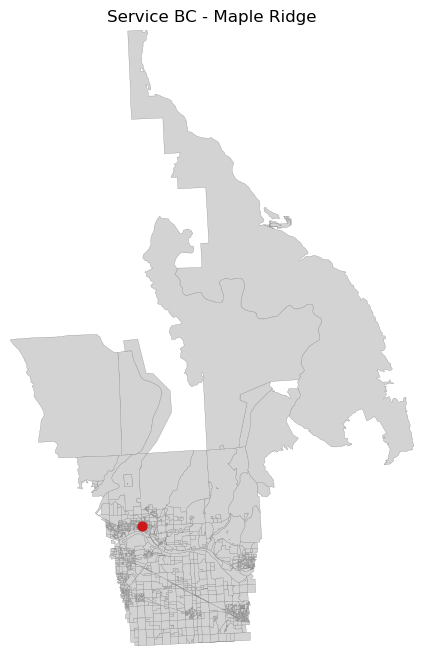

In [41]:
FACILITIES_CSV = INPUT_DIR / "full-service-bc-locs-wgs84_updated.xls"
# =============================================================================
# Main: code comparable to R
# =============================================================================

def main():
    ensure_dir(OUTPUT_DIRECTORY)

    # -------------------------------------------------------------------------
    # Read facilities CSV and convert to GeoDataFrame
    # -------------------------------------------------------------------------
    facilities_raw = pd.read_csv(FACILITIES_CSV)
    facilities_raw.columns = clean_names(facilities_raw.columns)

    required_fac_cols = {"nearest_facility", "coord_x", "coord_y"}
    missing = required_fac_cols - set(facilities_raw.columns)
    if missing:
        raise ValueError(f"Facility CSV missing columns: {', '.join(sorted(missing))}")

    facilities = gpd.GeoDataFrame(
        facilities_raw.copy(),
        geometry=gpd.points_from_xy(facilities_raw["coord_x"], facilities_raw["coord_y"]),
        crs="EPSG:4326"
    ).to_crs("EPSG:3005")
    facilities = facilities.drop_duplicates(subset=["nearest_facility"]).copy()

    # -------------------------------------------------------------------------
    # Download DB geometries (WFS via bcdata)
    # -------------------------------------------------------------------------
    print("Downloading dissemination block geometries (WFS via bcdata)...")
    db_gdf = get_wfs_geodata(DB_LAYER_KEY, crs="EPSG:3005")
    db_gdf.columns = clean_names(db_gdf.columns)

    rename_map = {
        "dissemination_block_id": "dbid",
        "dissemination_area_id": "daid",
        "census_subdivision_id": "csdid",
        "feature_area_sqm": "landarea",
    }
    for k, v in rename_map.items():
        if k in db_gdf.columns:
            db_gdf = db_gdf.rename(columns={k: v})

    needed = ["dbid", "daid", "csdid", "geometry"]
    for c in needed:
        if c not in db_gdf.columns:
            raise ValueError(f"DB layer missing expected column '{c}'. "
                             f"Available: {list(db_gdf.columns)}")

    db_gdf["dbid"] = db_gdf["dbid"].astype(str)
    db_gdf["csdid"] = db_gdf["csdid"].astype(str)

    # Compute area_sq_km from geometry
    db_gdf["area_sq_km"] = db_gdf.geometry.area / 1_000_000.0

    # -------------------------------------------------------------------------
    # Download CSD geometries (WFS via bcdata)
    # -------------------------------------------------------------------------
    print("Downloading CSD geometries (WFS via bcdata)...")
    csd_gdf = get_wfs_geodata(CSD_LAYER_KEY)
    csd_gdf.columns = clean_names(csd_gdf.columns)

    # Adjust mapping as needed
    csd_rename_map = {
        "census_subdivision_id": "csdid",
        "census_subdivision_name": "csd_name",
        "census_subdivision_type_desc": "csd_desc",
        "feature_area_sqm": "landarea"
    }
    for k, v in csd_rename_map.items():
        if k in csd_gdf.columns:
            csd_gdf = csd_gdf.rename(columns={k: v})

    for c in ["csdid", "csd_name", "csd_desc", "geometry"]:
        if c not in csd_gdf.columns:
            raise ValueError(f"CSD layer missing expected column '{c}'. "
                             f"Available: {list(csd_gdf.columns)}")

    csd_gdf["csdid"] = csd_gdf["csdid"].astype(str)

    # -------------------------------------------------------------------------
    # Download population projections (CKAN resource via requests)
    # -------------------------------------------------------------------------
    print("Downloading population projections (CKAN resource)...")
    pop_proj = download_bcdc_resource(POP_PROJ_PACKAGE_ID, POP_PROJ_RESOURCE_ID)
    pop_proj.columns = clean_names(pop_proj.columns)

    if "region" not in pop_proj.columns:
        raise ValueError("Population projections file must contain a 'region' column after clean_names().")

    pop_proj["region"] = pop_proj["region"].astype(str).str.zfill(5)
    pop_proj["region"] = PR + pop_proj["region"]

    # -------------------------------------------------------------------------
    # Cancensus / CensusMapper DB population (pycancensus)
    # -------------------------------------------------------------------------
    if os.getenv("CANCENSUS_API_KEY"):
        pc.set_api_key(os.getenv("CANCENSUS_API_KEY"))

    print("Downloading DB census data (pycancensus)...")
    try:
        pop_db = pc.get_census(
            dataset=CANCENSUS_YEAR,
            regions={"PR": PR},   # BC
            #vectors=["v_CA21_1"],
            level="DB",
            geo_format=None,
            quiet=False
        )
        pop_db.columns = clean_names(pop_db.columns)
    
    except:
        print("Initital cancensus downloading failed. Trying to download DB census data (pycancensus) with chunking...")
        pop_db, failed_csds = get_db_population_bc(
            dataset=CANCENSUS_YEAR, 
            pr=PR,
            vector=CENSUS_VECTORS,
            quiet=False
        )
        print("CSDs that required fallback / failed:", len(failed_csds))

    # Apply naming cleanup
    pop_db.columns = clean_names(pop_db.columns)

    print("Rows:", len(pop_db))
    

    # Standardize DB id and population
    if "geo_uid" in pop_db.columns:
        pop_db = pop_db.rename(columns={"geo_uid": "dbid"})
    elif "geouid" in pop_db.columns:
        pop_db = pop_db.rename(columns={"geouid": "dbid"})
    else:
        raise ValueError(f"pycancensus result missing GeoUID column; got columns: {list(pop_db.columns)}")

    pop_db["dbid"] = pop_db["dbid"].astype(str)
    pop_db["population"] = pd.to_numeric(pop_db["population"], errors="coerce").fillna(0.0)

    # -------------------------------------------------------------------------
    # Rural/urban matrix (excel)
    # -------------------------------------------------------------------------
    print("Reading rural/urban CSD matrix")
    rural = pd.read_excel(RURAL_MATRIX_XLSX, sheet_name="Census Subdivision Data")
    rural.columns = clean_names(rural.columns)

    if "csduid" not in rural.columns or "rural_category" not in rural.columns:
        raise ValueError(f"Rural matrix must have csduid and rural_category columns; got {list(rural.columns)}")

    csd_rural_category = rural.assign(
        csdid=rural["csduid"].astype(str),
        csd_name_excel=rural.get("name", pd.Series([None] * len(rural))).astype(str),
        urban_rural=rural["rural_category"].astype(str),
    )[["csdid", "csd_name_excel", "urban_rural"]]

    # -------------------------------------------------------------------------
    # Combine/merge DB -> CSD
    # -------------------------------------------------------------------------
    combined = (
        db_gdf.drop(columns=["geometry"])
        .merge(
            csd_gdf.drop(columns=["geometry"]),
            on="csdid",
            how="left",
            suffixes=("", "_csd")
        )
    )

    # -------------------------------------------------------------------------
    # DB population projections
    # -------------------------------------------------------------------------
    # Create 'csd_clean' label to match population projections
    proj_regions = pop_proj[["region"]].drop_duplicates().assign(in_projections=1)

    get_clean_csd = (
        pop_db.merge(combined[["dbid", "daid", "csdid", "csd_name", "csd_desc", "area_sq_km"]],
                     on="dbid", how="left")
        .merge(proj_regions, left_on="csdid", right_on="region", how="left")
    )

    # if rolled up, last 3 digits replaced with '999'
    get_clean_csd["csd_clean"] = get_clean_csd.apply(
        lambda r: (str(r["csdid"])[:4] + "999") if pd.isna(r["in_projections"]) else str(r["csdid"]),
        axis=1
    )

    # pct_of_csd by csd_clean (using base census population)
    csd_pop = get_clean_csd.groupby("csd_clean")["population"].transform("sum")
    prop_of_csd = get_clean_csd.copy()
    prop_of_csd["csd_population"] = csd_pop
    prop_of_csd["pct_of_csd"] = prop_of_csd.apply(
        lambda r: 0.0 if r["population"] == 0 else (r["population"] / r["csd_population"] if r["csd_population"] else 0.0),
        axis=1
    )

    # Join projections for years of interest
    proj_sub = pop_proj[pop_proj["year"].isin(PROJECTION_YEARS)].copy()
    db_proj = prop_of_csd.merge(
        proj_sub,
        left_on="csd_clean",
        right_on="region",
        how="left",
        suffixes=("", "_proj")
    )

    # Melt age columns 0, 1, ... into rows
    print(db_proj.head())
    age_cols = [c for c in db_proj.columns if str(c).isnumeric()]
    if not age_cols:
        raise ValueError("No age columns found matching numerix only fields in projections data.")

    db_proj_long = db_proj.melt(
        id_vars=[c for c in db_proj.columns if c not in age_cols],
        value_vars=age_cols,
        var_name="age_column",
        value_name="population_by_age"
    )
    db_proj_long["age"] = db_proj_long["age_column"].astype(int)

    # Apply pct_of_csd to distribute projected population to DBs
    db_proj_long["population"] = pd.to_numeric(db_proj_long["population_by_age"], errors="coerce").fillna(0.0) \
                                 * db_proj_long["pct_of_csd"]

    if "total" in db_proj_long.columns:
        db_proj_long["total"] = pd.to_numeric(db_proj_long["total"], errors="coerce").fillna(0.0) \
                                * db_proj_long["pct_of_csd"]

    # -------------------------------------------------------------------------
    # Assign DBs to nearest facilities (centroids)
    # -------------------------------------------------------------------------
    print("Assigning DBs to nearest facility using centroids...")
    facility_empty = pd.DataFrame({"dbid": pd.Series(dtype=str), "assigned": pd.Series(dtype=str)})

    db_assignments_raw = assign_dbs(
        db_gdf=db_gdf,
        assigned_facility=facility_empty,
        facility_locations=facilities[["nearest_facility", "geometry"]].copy(),
        verbose=True
    )

    db_assignments = db_assignments_raw.rename(
        columns={"assigned": "assigned_facility", "min_distance": "centroid_distance_m"}
    )

    # -------------------------------------------------------------------------
    # DB-level population estimates for the 3 projection years
    # -------------------------------------------------------------------------
    # Filter gender == "T" if present; otherwise assume totals already
    if "gender" in db_proj_long.columns:
        dbp = db_proj_long[db_proj_long["gender"] == "T"].copy()
    else:
        dbp = db_proj_long.copy()

    db_pop_3yr = (
        dbp[dbp["year"].isin(PROJECTION_YEARS)]
        .groupby(["dbid", "year"], as_index=False)["population"].sum()
        .pivot(index="dbid", columns="year", values="population")
        .fillna(0.0)
        .reset_index()
    )
    # Rename to pop_YYYY
    rename_years = {CURRENT_YEAR: f"pop_{CURRENT_YEAR}",
                    CURRENT_YEAR + 5: f"pop_{CURRENT_YEAR + 5}",
                    CURRENT_YEAR + 10: f"pop_{CURRENT_YEAR + 10}"}
    db_pop_3yr = db_pop_3yr.rename(columns=rename_years)

    # -------------------------------------------------------------------------
    # CSV 1: DB assignments list
    # -------------------------------------------------------------------------
    db_with_assignment = (
        combined[["dbid", "csdid", "csd_name"]].drop_duplicates()
        .merge(db_pop_3yr, on="dbid", how="left")
        .merge(db_assignments[["dbid", "assigned_facility", "centroid_distance_m"]], on="dbid", how="left")
        .merge(csd_rural_category[["csdid", "urban_rural"]], on="csdid", how="left")
    )

    # -------------------------------------------------------------------------
    # Facility rollups for CSV 2
    # -------------------------------------------------------------------------
    base_assign = (
        db_assignments.merge(combined[["dbid", "csdid", "csd_name"]].drop_duplicates(), on="dbid", how="left")
        [["assigned_facility", "assignment_method", "dbid", "csdid", "csd_name"]]
        .drop_duplicates()
    )

    years_df = pd.DataFrame({"year": PROJECTION_YEARS})
    base_assign_years = base_assign.merge(years_df, how="cross")

    db_proj_sel = db_proj_long.copy()
    if "gender" in db_proj_sel.columns:
        db_proj_sel = db_proj_sel[db_proj_sel["gender"] == "T"].copy()

    facility_all = (
        base_assign_years.merge(
            db_proj_sel[["dbid", "year", "age", "population"]],
            on=["dbid", "year"],
            how="left"
        )
    )
    facility_all = facility_all[facility_all["csdid"].notna()].copy()

    # Facility totals per year
    fac_totals = (
        facility_all.groupby(["assigned_facility", "year"], as_index=False)["population"].sum()
        .pivot(index="assigned_facility", columns="year", values="population")
        .fillna(0.0)
        .reset_index()
        .rename(columns=rename_years)
    )

    # Age bands for CURRENT_YEAR
    fac_curr = facility_all[facility_all["year"] == CURRENT_YEAR].copy()
    fac_age_bands = fac_curr.groupby("assigned_facility").apply(
        lambda g: pd.Series({
            "est_population_0_to_14_yrs": g.loc[(g["age"] >= 0) & (g["age"] < 15), "population"].sum(skipna=True),
            "est_population_15_to_24_yrs": g.loc[(g["age"] >= 15) & (g["age"] < 25), "population"].sum(skipna=True),
            "est_population_25_to_64_yrs": g.loc[(g["age"] >= 25) & (g["age"] < 65), "population"].sum(skipna=True),
            "est_population_over_64_yrs": g.loc[(g["age"] >= 65), "population"].sum(skipna=True),
        })
    ).reset_index()

    # Weighted median/mean age (CURRENT_YEAR)
    fac_age_dist = (
        fac_curr.groupby(["assigned_facility", "age"], as_index=False)["population"].sum()
    )

    fac_stats = fac_age_dist.groupby("assigned_facility").apply(
        lambda g: pd.Series({
            "median_age": weighted_median(g["age"].values, g["population"].values),
            "mean_age": float((g["age"] * g["population"]).sum() / g["population"].sum()) if g["population"].sum() > 0 else float("nan")
        })
    ).reset_index()

    facility_demographics = (
        fac_totals.merge(fac_age_bands, on="assigned_facility", how="left")
        .merge(fac_stats, on="assigned_facility", how="left")
        .rename(columns={"assigned_facility": "facility"})
    )

    # -------------------------------------------------------------------------
    # Write outputs
    # -------------------------------------------------------------------------
    print(f"Writing outputs to {OUTPUT_DIRECTORY} ...")

    csv1_path = os.path.join(OUTPUT_DIRECTORY, "db_centroid_assignments.csv")
    csv2_path = os.path.join(OUTPUT_DIRECTORY, "facility_population_projections.csv")

    shp_dir = os.path.join(OUTPUT_DIRECTORY, "facility_catchments")
    ensure_dir(shp_dir)
    shp_path = os.path.join(shp_dir, "sbc-catchments.shp")

    # Round numeric columns similarly to the R script
    for c in [f"pop_{CURRENT_YEAR}", f"pop_{CURRENT_YEAR+5}", f"pop_{CURRENT_YEAR+10}"]:
        if c in db_with_assignment.columns:
            db_with_assignment[c] = db_with_assignment[c].round(1)
    if "centroid_distance_m" in db_with_assignment.columns:
        db_with_assignment["centroid_distance_m"] = db_with_assignment["centroid_distance_m"].round(1)

    db_with_assignment.to_csv(csv1_path, index=False)

    for c in [f"pop_{CURRENT_YEAR}", f"pop_{CURRENT_YEAR+5}", f"pop_{CURRENT_YEAR+10}"]:
        if c in facility_demographics.columns:
            facility_demographics[c] = facility_demographics[c].round(1)
    for c in ["est_population_0_to_14_yrs", "est_population_15_to_24_yrs",
              "est_population_25_to_64_yrs", "est_population_over_64_yrs",
              "median_age", "mean_age"]:
        if c in facility_demographics.columns:
            facility_demographics[c] = facility_demographics[c].round(1)

    facility_demographics.to_csv(csv2_path, index=False)

    # Catchment dissolve + simplify
    catchments = db_gdf.merge(db_assignments[["dbid", "assigned_facility"]], on="dbid", how="left")
    catchments = catchments[catchments["assigned_facility"].notna()].copy()

    catchments_dissolved = catchments.dissolve(by="assigned_facility", as_index=False)

    # Simplify:
    # (R used keep=0.01; not directly equivalent)
    catchments_dissolved["geometry"] = catchments_dissolved.geometry.simplify(tolerance=250, preserve_topology=True)

    catchments_dissolved.to_file(shp_path)

    print("\nOutputs written to:")
    print(f"  - {csv1_path}")
    print(f"  - {csv2_path}")
    print(f"  - {shp_dir}")

    # -------------------------------------------------------------------------
    # Optional test visualization (geopandas plot)
    # -------------------------------------------------------------------------
    selected_facility_name = "Service BC - Maple Ridge"

    sel_polys = catchments[catchments["assigned_facility"] == selected_facility_name]
    if sel_polys.empty:
        print("\nNo DBs found for selected facility name; pick an exact facility from db_assignments.")
        return

    sel_point = facilities[facilities["nearest_facility"] == selected_facility_name]
    if sel_point.empty:
        print("\nSelected facility point not found in facilities CSV.")
        return

    # Bounding box for zoom
    minx, miny, maxx, maxy = sel_polys.total_bounds

    ax = sel_polys.plot(color="lightgrey", edgecolor="grey", linewidth=0.2, figsize=(8, 8))
    sel_point.plot(ax=ax, color="#cb181d", markersize=40)
    ax.set_xlim(minx, maxx)
    ax.set_ylim(miny, maxy)
    ax.set_axis_off()
    ax.set_title(selected_facility_name)
    #plt.show() #Uncomment this line to get a map plot showing the catchment area of one of the SBC offices.


if __name__ == "__main__":
    main()

# Taking new location as input and output with combination level folder 

In [43]:
# =============================================================================
# Updated scenario-based helper functions and main function
# =============================================================================

import os
import re
import hashlib  # Change: Create stable short hashes for long output folder names.
from pathlib import Path

import pandas as pd
import geopandas as gpd


# -----------------------------------------------------------------------
# Constants for safe Windows path handling
# -----------------------------------------------------------------------

MAX_WINDOWS_SAFE_FULL_PATH_LEN = 240
DEFAULT_MAX_FOLDER_COMPONENT_LEN = 60


# -----------------------------------------------------------------------
# Function: get_short_hash
#
# Description: Create a stable short hash for long path components.
#
# Inputs:
#   - value: value to hash
#   - length: hash length
#
# Outputs:
#   - short lowercase hexadecimal hash
# ------------------------------------------------------------------------

def get_short_hash(value: str, length: int = 8) -> str:
    # Change: Stable hash keeps shortened folder names unique.
    return hashlib.sha1(str(value).encode("utf-8")).hexdigest()[:length]


# -----------------------------------------------------------------------
# Function: sanitize_for_path
#
# Description: Convert a scenario or facility name into a safe folder name.
#              Optionally shorten long folder components and append a hash.
#
# Inputs:
#   - value: scenario name or facility name
#   - max_len: optional max folder component length
#   - fallback: fallback value if sanitized string becomes empty
#
# Outputs:
#   - safe lowercase folder name with special characters replaced by "_"
#
# Assumptions:
#   - folder names should be readable, stable, and Windows-safe
# ------------------------------------------------------------------------

def sanitize_for_path(
    value: str,
    max_len: int = None,
    fallback: str = "output"
) -> str:
    # Change: Convert value to a safe output-folder name.
    raw_value = str(value).strip().lower()
    safe_value = re.sub(r"[^a-z0-9]+", "_", raw_value)
    safe_value = re.sub(r"_+", "_", safe_value).strip("_")

    if not safe_value:
        safe_value = fallback

    # Change: Shorten long folder components and append hash to avoid collisions.
    if max_len is not None and len(safe_value) > max_len:
        suffix = get_short_hash(safe_value)
        keep_len = max(1, max_len - len(suffix) - 1)
        safe_value = f"{safe_value[:keep_len].rstrip('_')}_{suffix}"

    return safe_value


# -----------------------------------------------------------------------
# Function: normalize_to_list
#
# Description: Normalize list-like inputs to a simple Python list.
#              This also fixes accidental tuple-of-list inputs caused by:
#                  new_csd_names = [...],
#
# Inputs:
#   - values: scalar, list, tuple, set, pd.Series, or None
#
# Outputs:
#   - list
# ------------------------------------------------------------------------

def normalize_to_list(values) -> list:
    # Change: Handle None consistently.
    if values is None:
        return []

    # Change: Treat a single string as one item, not a sequence of characters.
    if isinstance(values, str):
        return [values]

    # Change: Convert pandas Series to list.
    if isinstance(values, pd.Series):
        return values.tolist()

    # Change: Fix accidental tuple containing one list, e.g. new_csd_names = [...],
    if isinstance(values, tuple) and len(values) == 1 and isinstance(
        values[0],
        (list, tuple, set, pd.Series)
    ):
        return normalize_to_list(values[0])

    if isinstance(values, (list, tuple, set)):
        return list(values)

    # Change: Keep scalar fallback safe.
    return [values]


# -----------------------------------------------------------------------
# Function: get_unique_values_preserve_order
#
# Description: Remove duplicate location names while preserving user-provided
#              order. This keeps output folder names stable and readable.
#
# Inputs:
#   - values: list-like object
#
# Outputs:
#   - list of unique non-empty string values
# ------------------------------------------------------------------------

def get_unique_values_preserve_order(values: list) -> list:
    # Change: Preserve input order while removing duplicate location labels.
    values = normalize_to_list(values)

    seen = set()
    result = []

    for value in values:
        value_clean = str(value).strip()

        if not value_clean:
            continue

        value_key = value_clean.lower()

        if value_key not in seen:
            seen.add(value_key)
            result.append(value_clean)

    return result


# -----------------------------------------------------------------------
# Function: build_added_locations_output_folder_name
#
# Description: Build a readable but short output folder name from the provided
#              new location combination.
#
# Inputs:
#   - new_csd_names: list of CSD-based new locations
#   - manual_facilities: optional manual facility table
#   - prefix: folder prefix
#   - max_len: max folder component length
#
# Outputs:
#   - safe folder name
#
# Assumptions:
#   - Full location details should not be stored only in the folder name
#   - Full scenario detail can be stored in output metadata if needed
# ------------------------------------------------------------------------

def build_added_locations_output_folder_name(
    new_csd_names: list = None,
    manual_facilities: pd.DataFrame = None,
    prefix: str = "add",
    max_len: int = DEFAULT_MAX_FOLDER_COMPONENT_LEN
) -> str:
    location_labels = []

    # Change: Add CSD-based location names to output folder label.
    for csd_name in get_unique_values_preserve_order(new_csd_names or []):
        if str(csd_name).strip():
            location_labels.append(str(csd_name).strip())

    # Change: Add manual facility names to output folder label if provided.
    if manual_facilities is not None and not manual_facilities.empty:
        if "nearest_facility" not in manual_facilities.columns:
            raise ValueError(
                "manual_facilities must contain nearest_facility column "
                "to build output folder name."
            )

        for facility_name in manual_facilities["nearest_facility"].dropna():
            facility_label = str(facility_name).strip()

            # Change: Remove common prefix to keep folder name readable.
            facility_label = re.sub(
                r"(?i)^sbc\s+service\s+cent(er|re)\s*-\s*",
                "",
                facility_label
            )

            if facility_label:
                location_labels.append(facility_label)

    location_labels = get_unique_values_preserve_order(location_labels)

    if not location_labels:
        return sanitize_for_path(
            f"{prefix}_no_new_locations",
            max_len=max_len,
            fallback=f"{prefix}_no_new_locations"
        )

    safe_labels = [
        sanitize_for_path(label)
        for label in location_labels
        if sanitize_for_path(label)
    ]

    if not safe_labels:
        return sanitize_for_path(
            f"{prefix}_new_locations",
            max_len=max_len,
            fallback=f"{prefix}_new_locations"
        )

    full_location_part = "_and_".join(safe_labels)
    location_hash = get_short_hash(full_location_part)

    # Change: Avoid very long folder names when many locations are added.
    if len(safe_labels) > 4:
        readable_part = "_and_".join(safe_labels[:3])
        folder_name = (
            f"{prefix}_{len(safe_labels)}_locations_"
            f"{readable_part}_{location_hash}"
        )
    else:
        folder_name = f"{prefix}_{full_location_part}"

    return sanitize_for_path(
        folder_name,
        max_len=max_len,
        fallback=f"{prefix}_new_locations"
    )


# -----------------------------------------------------------------------
# Function: get_safe_output_subfolder
#
# Description: Create a location-combination output folder under
#              OUTPUT_DIRECTORY. If the folder already exists and
#              allow_overwrite=False, create a numbered run folder instead.
#
# Inputs:
#   - output_root: base output directory
#   - folder_name: target subfolder name
#   - allow_overwrite: whether to reuse an existing folder
#   - max_folder_len: max folder component length
#   - max_full_path_len: conservative full path limit
#   - reserved_child_path_len: reserved length for scenario/shapefile children
#
# Outputs:
#   - string path to output subfolder
#
# Assumptions:
#   - New location combinations should get deterministic folder names
#   - Re-running the same combination should not overwrite unless allowed
# ------------------------------------------------------------------------

def get_safe_output_subfolder(
    output_root: str,
    folder_name: str,
    allow_overwrite: bool = False,
    max_folder_len: int = DEFAULT_MAX_FOLDER_COMPONENT_LEN,
    max_full_path_len: int = MAX_WINDOWS_SAFE_FULL_PATH_LEN,
    reserved_child_path_len: int = 110
) -> str:
    output_root = Path(output_root)
    output_root.mkdir(parents=True, exist_ok=True)

    output_root_str = str(output_root)

    # Change: Reserve room for scenario folder + shapefile subfolder/file.
    available_folder_len = (
        max_full_path_len
        - len(output_root_str)
        - 1
        - reserved_child_path_len
    )

    if available_folder_len < 20:
        raise ValueError(
            "OUTPUT_DIRECTORY is too long for nested scenario outputs. "
            "Use a shorter OUTPUT_DIRECTORY, for example: "
            r"C:\temp\sbc_output"
        )

    folder_len = min(max_folder_len, available_folder_len)

    # Change: Force safe short combination folder name.
    folder_name = sanitize_for_path(
        folder_name,
        max_len=folder_len,
        fallback="scenario"
    )

    base_dir = output_root / folder_name

    if allow_overwrite:
        # Change: Reuse existing combination output folder if explicitly allowed.
        base_dir.mkdir(parents=True, exist_ok=True)
        return str(base_dir)

    if not base_dir.exists():
        # Change: Use clean folder name for the first run of this combination.
        base_dir.mkdir(parents=True, exist_ok=False)
        return str(base_dir)

    # Change: Prevent overwrite when the same combination is rerun.
    run_number = 2

    while True:
        suffix = f"_run_{run_number:03d}"

        # Change: Keep run folder under the same path length limit.
        candidate_base = sanitize_for_path(
            folder_name,
            max_len=max(1, folder_len - len(suffix)),
            fallback="scenario"
        )

        candidate_dir = output_root / f"{candidate_base}{suffix}"

        if not candidate_dir.exists():
            candidate_dir.mkdir(parents=True, exist_ok=False)
            return str(candidate_dir)

        run_number += 1


# -----------------------------------------------------------------------
# Function: get_empty_manual_facilities
#
# Description: Create an empty manual facility DataFrame with the required
#              structure. This avoids errors when a scenario only adds CSD
#              representative points and no manual address-based point.
#
# Inputs:
#   - None
#
# Outputs:
#   - Empty DataFrame with columns:
#       nearest_facility | coord_x | coord_y
#
# Assumptions:
#   - coord_x is longitude
#   - coord_y is latitude
#   - manual coordinates are EPSG:4326
# ------------------------------------------------------------------------

def get_empty_manual_facilities() -> pd.DataFrame:
    # Change: Standard empty structure for scenarios without manual locations.
    return pd.DataFrame(columns=["nearest_facility", "coord_x", "coord_y"])


# -----------------------------------------------------------------------
# Function: update_facilities_csv
#
# Description: Prepare the base facility CSV before scenario modelling.
#              This function:
#                   - removes selected existing facilities
#                   - renames selected existing facilities
#                   - writes an updated CSV in the same input folder
#
# Inputs:
#   - facilities_csv_path: path to the original facility CSV
#   - removal_list: list of facility names or keywords to remove
#   - rename_map: dictionary of old facility name -> new facility name
#   - output_filename: name of the updated facility CSV
#   - match_mode:
#       "exact"    = remove exact nearest_facility matches only
#       "contains" = remove rows where nearest_facility contains the value
#
# Outputs:
#   - output_path: path to the updated facility CSV
#
# Assumptions:
#   - Facility CSV contains a nearest_facility column
#   - Existing facility coordinates remain unchanged
#   - Rename happens before removal
# ------------------------------------------------------------------------

def update_facilities_csv(
    facilities_csv_path,
    removal_list: list = None,
    rename_map: dict = None,
    output_filename: str = "full-service-bc-locs-wgs84_updated.csv",
    match_mode: str = "contains"
) -> str:
    # Change: Ensure path object can resolve parent folder.
    facilities_csv_path = Path(facilities_csv_path)
    output_path = facilities_csv_path.parent / output_filename

    if not facilities_csv_path.exists():
        raise FileNotFoundError(f"Facility CSV not found: {facilities_csv_path}")

    # Change: Read original facility table.
    df = pd.read_csv(facilities_csv_path)

    # Change: Preserve original column names but locate nearest_facility robustly.
    cleaned_col_map = {
        re.sub(r"[^a-z0-9]+", "_", str(col).strip().lower()).strip("_"): col
        for col in df.columns
    }

    if "nearest_facility" not in cleaned_col_map:
        raise ValueError(
            "Facility CSV must contain a nearest_facility column. "
            f"Available columns: {list(df.columns)}"
        )

    facility_col = cleaned_col_map["nearest_facility"]

    print("Original facility row count:", len(df))

    # ---------------------------------------------------------------------
    # Rename selected facilities
    # ---------------------------------------------------------------------
    if rename_map:
        rename_map_clean = {
            str(old).strip().lower(): str(new).strip()
            for old, new in rename_map.items()
            if str(old).strip() and str(new).strip()
        }

        facility_names_clean = df[facility_col].astype(str).str.strip().str.lower()

        for old_name_clean, new_name in rename_map_clean.items():
            rename_mask = facility_names_clean == old_name_clean
            rename_count = int(rename_mask.sum())

            if rename_count == 0:
                print(f"Warning: no facility matched rename source: {old_name_clean}")
            else:
                print(f"Renaming {rename_count} row(s): {old_name_clean} -> {new_name}")
                df.loc[rename_mask, facility_col] = new_name

        # Change: Refresh cleaned names after rename.
        facility_names_clean = df[facility_col].astype(str).str.strip().str.lower()
    else:
        facility_names_clean = df[facility_col].astype(str).str.strip().str.lower()

    # ---------------------------------------------------------------------
    # Remove selected facilities
    # ---------------------------------------------------------------------
    removal_list = removal_list or []
    removal_clean = [
        str(x).strip().lower()
        for x in removal_list
        if str(x).strip()
    ]

    if removal_clean:
        if match_mode == "exact":
            remove_mask = facility_names_clean.isin(removal_clean)

        elif match_mode == "contains":
            remove_mask = pd.Series(False, index=df.index)

            for removal_value in removal_clean:
                remove_mask = remove_mask | facility_names_clean.str.contains(
                    re.escape(removal_value),
                    case=False,
                    na=False
                )

        else:
            raise ValueError("match_mode must be either 'exact' or 'contains'.")

        removed_rows = df.loc[remove_mask].copy()
        df = df.loc[~remove_mask].copy()

        print("Removed facility row count:", len(removed_rows))

        if removed_rows.empty:
            print("Warning: no facilities matched the removal_list.")
        else:
            print("Removed facilities:")
            print(removed_rows[[facility_col]].drop_duplicates().to_string(index=False))

    print("Final facility row count:", len(df))

    # Change: Write updated CSV to the same folder as FACILITIES_CSV.
    df.to_csv(output_path, index=False)
    print(f"Updated facility CSV written to: {output_path}")

    return str(output_path)


# -----------------------------------------------------------------------
# Function: load_facilities_as_gdf
#
# Description: Read the updated facility CSV and convert it to a GeoDataFrame.
#              The output is used as the base facility table for all scenarios.
#
# Inputs:
#   - facilities_csv_path: path to the updated facility CSV
#
# Outputs:
#   - GeoDataFrame with nearest_facility and geometry in EPSG:3005
#
# Assumptions:
#   - coord_x is longitude in EPSG:4326
#   - coord_y is latitude in EPSG:4326
#   - nearest_facility uniquely identifies each office
# ------------------------------------------------------------------------

def load_facilities_as_gdf(facilities_csv_path: str) -> gpd.GeoDataFrame:
    # Change: Read updated facility CSV.
    facilities_raw = pd.read_csv(facilities_csv_path)
    facilities_raw.columns = clean_names(facilities_raw.columns)

    required_fac_cols = {"nearest_facility", "coord_x", "coord_y"}
    missing = required_fac_cols - set(facilities_raw.columns)

    if missing:
        raise ValueError(
            f"Facility CSV missing columns after clean_names(): {', '.join(sorted(missing))}"
        )

    # Change: Validate coordinate fields.
    facilities_raw["coord_x"] = pd.to_numeric(facilities_raw["coord_x"], errors="coerce")
    facilities_raw["coord_y"] = pd.to_numeric(facilities_raw["coord_y"], errors="coerce")

    invalid_rows = facilities_raw[
        facilities_raw["coord_x"].isna() | facilities_raw["coord_y"].isna()
    ]

    if not invalid_rows.empty:
        raise ValueError(
            "Facility CSV contains invalid coord_x / coord_y values. "
            f"Invalid row count: {len(invalid_rows)}"
        )

    # Change: Convert longitude/latitude to BC Albers for distance calculations.
    facilities = gpd.GeoDataFrame(
        facilities_raw.copy(),
        geometry=gpd.points_from_xy(
            facilities_raw["coord_x"],
            facilities_raw["coord_y"]
        ),
        crs="EPSG:4326"
    ).to_crs("EPSG:3005")

    facilities = (
        facilities[["nearest_facility", "geometry"]]
        .drop_duplicates(subset=["nearest_facility"])
        .reset_index(drop=True)
    )

    return facilities


# -----------------------------------------------------------------------
# Function: build_updated_facility_locations_from_inputs
#
# Description: Build a scenario-specific facility table by combining:
#                   - the updated base Service BC facility list
#                   - selected CSD representative points
#                   - selected manual address-based facility points
#
# Inputs:
#   - facilities: base facility GeoDataFrame in EPSG:3005
#   - csd_gdf: CSD GeoDataFrame with csdid, csd_name, and geometry
#   - new_csd_names: list of CSD names to add as representative points
#   - manual_facilities: DataFrame with nearest_facility, coord_x, coord_y
#
# Outputs:
#   - SBC_facility_names_updated: scenario-specific GeoDataFrame with:
#       nearest_facility | geometry
#
# Assumptions:
#   - CSD names are matched exactly after lower/strip normalization
#   - CSD representative_point() is used instead of centroid so the point
#     remains inside the CSD polygon
#   - Manual coordinates are EPSG:4326 and converted to EPSG:3005
# ------------------------------------------------------------------------

def build_updated_facility_locations_from_inputs(
    facilities: gpd.GeoDataFrame,
    csd_gdf: gpd.GeoDataFrame,
    new_csd_names: list = None,
    manual_facilities: pd.DataFrame = None
) -> gpd.GeoDataFrame:
    # Change: Normalize list input to avoid tuple-of-list errors.
    new_csd_names = get_unique_values_preserve_order(new_csd_names or [])

    if manual_facilities is None:
        manual_facilities = get_empty_manual_facilities()

    # ---------------------------------------------------------------------
    # Prepare base facility list
    # ---------------------------------------------------------------------
    if facilities.crs is None:
        raise ValueError("facilities must have a CRS.")

    facilities_base = facilities[["nearest_facility", "geometry"]].copy()

    if facilities_base.crs.to_epsg() != 3005:
        facilities_base = facilities_base.to_crs("EPSG:3005")

    facilities_base = (
        facilities_base
        .drop_duplicates(subset=["nearest_facility"])
        .reset_index(drop=True)
    )

    # ---------------------------------------------------------------------
    # Convert selected CSD polygons to representative facility points
    # ---------------------------------------------------------------------
    if new_csd_names:
        csd_work = csd_gdf.copy()

        if csd_work.crs is None:
            raise ValueError("csd_gdf must have a CRS.")

        if csd_work.crs.to_epsg() != 3005:
            csd_work = csd_work.to_crs("EPSG:3005")

        required_csd_cols = {"csdid", "csd_name", "geometry"}
        missing_csd_cols = required_csd_cols - set(csd_work.columns)

        if missing_csd_cols:
            raise ValueError(
                f"csd_gdf missing required columns: {sorted(missing_csd_cols)}"
            )

        csd_work["csd_name_clean"] = (
            csd_work["csd_name"]
            .astype(str)
            .str.strip()
            .str.lower()
        )

        requested_csd_names = [
            str(x).strip().lower()
            for x in new_csd_names
            if str(x).strip()
        ]

        matched_csds = csd_work[
            csd_work["csd_name_clean"].isin(requested_csd_names)
        ].copy()

        matched_names = set(matched_csds["csd_name_clean"])
        missing_csds = sorted(set(requested_csd_names) - matched_names)

        if missing_csds:
            available_examples = (
                csd_work[["csdid", "csd_name"]]
                .drop_duplicates()
                .sort_values("csd_name")
                .head(30)
            )

            raise ValueError(
                "Requested CSD names were not found in csd_gdf: "
                f"{missing_csds}. "
                f"Available examples: {available_examples.to_dict(orient='records')}"
            )

        csd_candidate_facilities = matched_csds[
            ["csdid", "csd_name", "geometry"]
        ].copy()

        # Change: representative_point keeps point inside polygon.
        csd_candidate_facilities["geometry"] = (
            csd_candidate_facilities.geometry.representative_point()
        )

        csd_candidate_facilities["nearest_facility"] = (
            "SBC service center - "
            + csd_candidate_facilities["csd_name"].astype(str)
        )

        csd_candidate_facilities = csd_candidate_facilities[
            ["nearest_facility", "geometry"]
        ].copy()

    else:
        # Change: Empty GeoDataFrame for scenarios without CSD additions.
        csd_candidate_facilities = gpd.GeoDataFrame(
            {"nearest_facility": [], "geometry": []},
            geometry="geometry",
            crs="EPSG:3005"
        )

    # ---------------------------------------------------------------------
    # Convert manual address-based facilities to GeoDataFrame
    # ---------------------------------------------------------------------
    if manual_facilities is not None and not manual_facilities.empty:
        manual_facility_cols = {"nearest_facility", "coord_x", "coord_y"}
        missing_manual_cols = manual_facility_cols - set(manual_facilities.columns)

        if missing_manual_cols:
            raise ValueError(
                f"manual_facilities missing required columns: {sorted(missing_manual_cols)}"
            )

        manual_facilities_clean = manual_facilities.copy()

        manual_facilities_clean["coord_x"] = pd.to_numeric(
            manual_facilities_clean["coord_x"],
            errors="coerce"
        )
        manual_facilities_clean["coord_y"] = pd.to_numeric(
            manual_facilities_clean["coord_y"],
            errors="coerce"
        )

        invalid_manual_rows = manual_facilities_clean[
            manual_facilities_clean["coord_x"].isna()
            | manual_facilities_clean["coord_y"].isna()
        ]

        if not invalid_manual_rows.empty:
            raise ValueError(
                "manual_facilities contains invalid coord_x / coord_y values. "
                f"Invalid row count: {len(invalid_manual_rows)}"
            )

        # Change: Convert manual longitude/latitude to EPSG:3005.
        manual_facilities_gdf = gpd.GeoDataFrame(
            manual_facilities_clean.copy(),
            geometry=gpd.points_from_xy(
                manual_facilities_clean["coord_x"],
                manual_facilities_clean["coord_y"]
            ),
            crs="EPSG:4326"
        ).to_crs("EPSG:3005")

        manual_facilities_gdf = manual_facilities_gdf[
            ["nearest_facility", "geometry"]
        ].copy()

    else:
        # Change: Empty GeoDataFrame for scenarios without manual additions.
        manual_facilities_gdf = gpd.GeoDataFrame(
            {"nearest_facility": [], "geometry": []},
            geometry="geometry",
            crs="EPSG:3005"
        )

    # ---------------------------------------------------------------------
    # Combine base facilities + scenario additions
    # ---------------------------------------------------------------------
    SBC_facility_names_updated = pd.concat(
        [
            facilities_base,
            csd_candidate_facilities,
            manual_facilities_gdf
        ],
        ignore_index=True
    )

    SBC_facility_names_updated = gpd.GeoDataFrame(
        SBC_facility_names_updated,
        geometry="geometry",
        crs="EPSG:3005"
    )

    SBC_facility_names_updated = (
        SBC_facility_names_updated
        .drop_duplicates(subset=["nearest_facility"])
        .reset_index(drop=True)
    )

    print("Base facility count:", len(facilities_base))
    print("CSD candidate facilities added:", len(csd_candidate_facilities))
    print("Manual facilities added:", len(manual_facilities_gdf))
    print("Updated total facility count:", len(SBC_facility_names_updated))

    return SBC_facility_names_updated


# -----------------------------------------------------------------------
# Function: build_location_scenarios
#
# Description: Build a list of scenario definitions. This supports:
#                   - one output folder per individual new CSD location
#                   - one output folder per individual manual location
#                   - one output folder for all new locations together
#
# Inputs:
#   - new_csd_names: list of CSD names
#   - manual_facilities: DataFrame of manual facilities
#   - include_individual: whether to run each new location separately
#   - include_all: whether to run all new locations together
#
# Outputs:
#   - list of dictionaries:
#       scenario_name
#       new_csd_names
#       manual_facilities
#
# Assumptions:
#   - Scenario names are later sanitized before being used as folder names
# ------------------------------------------------------------------------

def build_location_scenarios(
    new_csd_names: list,
    manual_facilities: pd.DataFrame,
    include_individual: bool = True,
    include_all: bool = True
) -> list:
    scenarios = []

    # Change: Remove duplicate CSD names while preserving order.
    new_csd_names = get_unique_values_preserve_order(new_csd_names or [])

    if manual_facilities is None:
        manual_facilities = get_empty_manual_facilities()

    # Change: Build one scenario per CSD location.
    if include_individual:
        for csd_name in new_csd_names:
            scenarios.append({
                "scenario_name": f"single_{csd_name}",
                "new_csd_names": [csd_name],
                "manual_facilities": get_empty_manual_facilities()
            })

        # Change: Build one scenario per manual location.
        if not manual_facilities.empty:
            for _, row in manual_facilities.iterrows():
                manual_one = pd.DataFrame([row])
                scenarios.append({
                    "scenario_name": f"single_{row['nearest_facility']}",
                    "new_csd_names": [],
                    "manual_facilities": manual_one
                })

    # Change: Build one scenario with every new location included.
    if include_all:
        scenarios.append({
            "scenario_name": "all_new_locations",
            "new_csd_names": new_csd_names,
            "manual_facilities": manual_facilities
        })

    if not scenarios:
        raise ValueError("No scenarios were created. Check include_individual/include_all settings.")

    return scenarios


# -----------------------------------------------------------------------
# Function: write_assignment_outputs_for_scenario
#
# Description: For one scenario, assign all DBs to the nearest facility using
#              the scenario-specific facility table, then write the required
#              output files:
#                   - db_centroid_assignments_updated.csv
#                   - facility_population_projections_updated.csv
#                   - facility_catchments_updated shapefile folder
#
# Inputs:
#   - scenario_name: label for this scenario
#   - output_root: base output directory
#   - db_gdf: DB geometry GeoDataFrame
#   - combined: DB-to-CSD non-geometry table
#   - db_proj_long: long-format DB population projection table
#   - csd_rural_category: CSD rural/urban lookup
#   - facility_locations: scenario-specific facility GeoDataFrame
#
# Outputs:
#   - dictionary with scenario output paths
#
# Assumptions:
#   - db_gdf and facility_locations are in compatible projected CRS
#   - centroid_distance_m is straight-line centroid distance in metres
#   - downstream CSV and shapefile are overwritten if the scenario folder exists
# ------------------------------------------------------------------------

def write_assignment_outputs_for_scenario(
    scenario_name: str,
    output_root: str,
    db_gdf: gpd.GeoDataFrame,
    combined: pd.DataFrame,
    db_proj_long: pd.DataFrame,
    csd_rural_category: pd.DataFrame,
    facility_locations: gpd.GeoDataFrame
) -> dict:
    # ---------------------------------------------------------------------
    # Prepare scenario output folder
    # ---------------------------------------------------------------------
    output_root = Path(output_root)

    # Change: Reserve room for shapefile folder and shapefile name.
    reserved_extra_len = len(
        os.path.join("facility_catchments_updated", "sbc-catchments_update.shp")
    ) + 1

    available_scenario_len = (
        MAX_WINDOWS_SAFE_FULL_PATH_LEN
        - len(str(output_root))
        - 1
        - reserved_extra_len
    )

    if available_scenario_len < 20:
        raise ValueError(
            "Scenario output path is too long. "
            "Use a shorter OUTPUT_DIRECTORY or shorter output_folder_name."
        )

    scenario_folder = sanitize_for_path(
        scenario_name,
        max_len=min(45, available_scenario_len),
        fallback="scenario"
    )

    scenario_output_dir = output_root / scenario_folder
    scenario_output_dir.mkdir(parents=True, exist_ok=True)

    print("\n============================================================")
    print(f"Running scenario: {scenario_name}")
    print(f"Output folder: {scenario_output_dir}")
    print("============================================================")

    # ---------------------------------------------------------------------
    # Assign DBs to nearest facilities for this scenario
    # ---------------------------------------------------------------------
    facility_empty = pd.DataFrame({
        "dbid": pd.Series(dtype=str),
        "assigned": pd.Series(dtype=str)
    })

    db_assignments_raw = assign_dbs(
        db_gdf=db_gdf,
        assigned_facility=facility_empty,
        facility_locations=facility_locations[["nearest_facility", "geometry"]].copy(),
        verbose=True
    )

    db_assignments = db_assignments_raw.rename(
        columns={
            "assigned": "assigned_facility",
            "min_distance": "centroid_distance_m"
        }
    )

    # ---------------------------------------------------------------------
    # Build DB population columns for selected projection years
    # ---------------------------------------------------------------------
    if "gender" in db_proj_long.columns:
        dbp = db_proj_long[db_proj_long["gender"] == "T"].copy()
    else:
        dbp = db_proj_long.copy()

    db_pop_3yr = (
        dbp[dbp["year"].isin(PROJECTION_YEARS)]
        .groupby(["dbid", "year"], as_index=False)["population"].sum()
        .pivot(index="dbid", columns="year", values="population")
        .fillna(0.0)
        .reset_index()
    )

    rename_years = {
        CURRENT_YEAR: f"pop_{CURRENT_YEAR}",
        CURRENT_YEAR + 5: f"pop_{CURRENT_YEAR + 5}",
        CURRENT_YEAR + 10: f"pop_{CURRENT_YEAR + 10}"
    }

    db_pop_3yr = db_pop_3yr.rename(columns=rename_years)

    # ---------------------------------------------------------------------
    # CSV 1: DB-level assignment output
    # ---------------------------------------------------------------------
    db_with_assignment = (
        combined[["dbid", "csdid", "csd_name"]].drop_duplicates()
        .merge(db_pop_3yr, on="dbid", how="left")
        .merge(
            db_assignments[
                ["dbid", "assigned_facility", "centroid_distance_m"]
            ],
            on="dbid",
            how="left"
        )
        .merge(
            csd_rural_category[["csdid", "urban_rural"]],
            on="csdid",
            how="left"
        )
    )

    # ---------------------------------------------------------------------
    # CSV 2: Facility-level population rollup
    # ---------------------------------------------------------------------
    base_assign = (
        db_assignments
        .merge(
            combined[["dbid", "csdid", "csd_name"]].drop_duplicates(),
            on="dbid",
            how="left"
        )
        [["assigned_facility", "assignment_method", "dbid", "csdid", "csd_name"]]
        .drop_duplicates()
    )

    years_df = pd.DataFrame({"year": PROJECTION_YEARS})
    base_assign_years = base_assign.merge(years_df, how="cross")

    db_proj_sel = db_proj_long.copy()

    if "gender" in db_proj_sel.columns:
        db_proj_sel = db_proj_sel[db_proj_sel["gender"] == "T"].copy()

    facility_all = (
        base_assign_years.merge(
            db_proj_sel[["dbid", "year", "age", "population"]],
            on=["dbid", "year"],
            how="left"
        )
    )

    facility_all = facility_all[facility_all["csdid"].notna()].copy()

    # Change: Facility totals by year.
    fac_totals = (
        facility_all
        .groupby(["assigned_facility", "year"], as_index=False)["population"]
        .sum()
        .pivot(index="assigned_facility", columns="year", values="population")
        .fillna(0.0)
        .reset_index()
        .rename(columns=rename_years)
    )

    # Change: Current-year age bands.
    fac_curr = facility_all[facility_all["year"] == CURRENT_YEAR].copy()

    fac_age_bands = fac_curr.groupby("assigned_facility").apply(
        lambda g: pd.Series({
            "est_population_0_to_14_yrs": g.loc[
                (g["age"] >= 0) & (g["age"] < 15),
                "population"
            ].sum(skipna=True),
            "est_population_15_to_24_yrs": g.loc[
                (g["age"] >= 15) & (g["age"] < 25),
                "population"
            ].sum(skipna=True),
            "est_population_25_to_64_yrs": g.loc[
                (g["age"] >= 25) & (g["age"] < 65),
                "population"
            ].sum(skipna=True),
            "est_population_over_64_yrs": g.loc[
                g["age"] >= 65,
                "population"
            ].sum(skipna=True),
        })
    ).reset_index()

    # Change: Weighted median and mean age.
    fac_age_dist = (
        fac_curr
        .groupby(["assigned_facility", "age"], as_index=False)["population"]
        .sum()
    )

    fac_stats = fac_age_dist.groupby("assigned_facility").apply(
        lambda g: pd.Series({
            "median_age": weighted_median(g["age"].values, g["population"].values),
            "mean_age": (
                float((g["age"] * g["population"]).sum() / g["population"].sum())
                if g["population"].sum() > 0
                else float("nan")
            )
        })
    ).reset_index()

    facility_demographics = (
        fac_totals
        .merge(fac_age_bands, on="assigned_facility", how="left")
        .merge(fac_stats, on="assigned_facility", how="left")
        .rename(columns={"assigned_facility": "facility"})
    )

    # ---------------------------------------------------------------------
    # Write output paths
    # ---------------------------------------------------------------------
    csv1_path = scenario_output_dir / "db_centroid_assignments_updated.csv"

    csv2_path = scenario_output_dir / "facility_population_projections_updated.csv"

    shp_dir = scenario_output_dir / "facility_catchments_updated"
    shp_dir.mkdir(parents=True, exist_ok=True)

    shp_path = shp_dir / "sbc-catchments_update.shp"

    # ---------------------------------------------------------------------
    # Round numeric outputs
    # ---------------------------------------------------------------------
    for c in [
        f"pop_{CURRENT_YEAR}",
        f"pop_{CURRENT_YEAR + 5}",
        f"pop_{CURRENT_YEAR + 10}"
    ]:
        if c in db_with_assignment.columns:
            db_with_assignment[c] = db_with_assignment[c].round(1)

        if c in facility_demographics.columns:
            facility_demographics[c] = facility_demographics[c].round(1)

    if "centroid_distance_m" in db_with_assignment.columns:
        db_with_assignment["centroid_distance_m"] = (
            db_with_assignment["centroid_distance_m"].round(1)
        )

    for c in [
        "est_population_0_to_14_yrs",
        "est_population_15_to_24_yrs",
        "est_population_25_to_64_yrs",
        "est_population_over_64_yrs",
        "median_age",
        "mean_age"
    ]:
        if c in facility_demographics.columns:
            facility_demographics[c] = facility_demographics[c].round(1)

    # ---------------------------------------------------------------------
    # Write CSV outputs
    # ---------------------------------------------------------------------
    db_with_assignment.to_csv(csv1_path, index=False)
    facility_demographics.to_csv(csv2_path, index=False)

    # ---------------------------------------------------------------------
    # Write catchment shapefile
    # ---------------------------------------------------------------------
    catchments = db_gdf.merge(
        db_assignments[["dbid", "assigned_facility"]],
        on="dbid",
        how="left"
    )

    catchments = catchments[
        catchments["assigned_facility"].notna()
    ].copy()

    catchments_dissolved = catchments.dissolve(
        by="assigned_facility",
        as_index=False
    )

    catchments_dissolved["geometry"] = (
        catchments_dissolved.geometry.simplify(
            tolerance=250,
            preserve_topology=True
        )
    )

    catchments_dissolved.to_file(shp_path)

    print("Outputs written:")
    print(f"  - {csv1_path}")
    print(f"  - {csv2_path}")
    print(f"  - {shp_dir}")

    return {
        "scenario_name": scenario_name,
        "scenario_output_dir": str(scenario_output_dir),
        "csv1_path": str(csv1_path),
        "csv2_path": str(csv2_path),
        "shp_dir": str(shp_dir)
    }


from pathlib import Path
import os
import pandas as pd
import geopandas as gpd
import bcdata


# -----------------------------------------------------------------------
# Helper: patch_bcdata_primary_keys
#
# Description:
#   Fix bcdata version mismatch where bcdata.wfs expects:
#       bcdata.primary_keys
#   but the installed bcdata module does not expose it.
#
# Observed error:
#   AttributeError: module 'bcdata' has no attribute 'primary_keys'
# ------------------------------------------------------------------------

def patch_bcdata_primary_keys():
    """
    Patch bcdata if the installed version does not expose primary_keys.
    """

    if not hasattr(bcdata, "primary_keys"):
        print("Debug: bcdata.primary_keys missing. Adding fallback dictionary.")
        bcdata.primary_keys = {}

    return bcdata.primary_keys


# -----------------------------------------------------------------------
# Function: get_wfs_geodata
#
# Description:
#   Download a BCGW / BC Data Catalogue WFS layer as a GeoDataFrame.
#
# Changes:
#   - Patches missing bcdata.primary_keys before download.
#   - Supports explicit sortby field.
#   - Falls back to no sortby if sortby fails.
#   - Converts dict-with-features result to GeoDataFrame if needed.
#   - Validates CRS and reprojects to target CRS.
# ------------------------------------------------------------------------

def get_wfs_geodata(
    layer_key: str,
    crs: str = "EPSG:3005",
    sortby: str = None
) -> gpd.GeoDataFrame:
    """
    Download a BCGW WFS layer as a GeoDataFrame.
    """

    # Change: Patch bcdata version mismatch before any WFS request.
    patch_bcdata_primary_keys()

    print("\nDownloading WFS layer:")
    print(f"  layer_key: {layer_key}")
    print(f"  target CRS: {crs}")
    print(f"  sortby: {sortby}")

    try:
        if sortby:
            try:
                gdf = bcdata.get_data(
                    layer_key,
                    as_gdf=True,
                    sortby=sortby
                )
            except TypeError:
                # Change: Some bcdata versions may not support as_gdf.
                gdf = bcdata.get_data(
                    layer_key,
                    sortby=sortby
                )
        else:
            try:
                gdf = bcdata.get_data(
                    layer_key,
                    as_gdf=True
                )
            except TypeError:
                gdf = bcdata.get_data(layer_key)

    except Exception as e:
        print("\nDebug: WFS download failed.")
        print("Reason:", repr(e))

        if sortby:
            print("Debug: Retrying without sortby...")

            try:
                gdf = bcdata.get_data(
                    layer_key,
                    as_gdf=True
                )
            except TypeError:
                gdf = bcdata.get_data(layer_key)

        else:
            raise

    # ---------------------------------------------------------------------
    # Validate result type
    # ---------------------------------------------------------------------
    print("Debug: downloaded object type:", type(gdf))

    if isinstance(gdf, dict):
        print("Debug: bcdata returned dict keys:", list(gdf.keys()))

        if "features" in gdf:
            gdf = gpd.GeoDataFrame.from_features(
                gdf["features"],
                crs="EPSG:4326"
            )
        else:
            raise TypeError(
                f"Expected GeoDataFrame, got dict without 'features'. "
                f"Object preview: {str(gdf)[:500]}"
            )

    if not isinstance(gdf, gpd.GeoDataFrame):
        raise TypeError(
            f"Expected GeoDataFrame from bcdata.get_data(), got {type(gdf)}. "
            f"Object preview: {str(gdf)[:500]}"
        )

    if gdf.empty:
        raise ValueError(f"Downloaded WFS layer is empty: {layer_key}")

    if gdf.crs is None:
        raise ValueError(
            f"Downloaded WFS layer has no CRS: {layer_key}. "
            "Cannot safely calculate centroid distances."
        )

    print("Debug: source CRS:", gdf.crs)
    print("Debug: row count:", len(gdf))
    print("Debug: columns:", list(gdf.columns))

    if crs is not None:
        gdf = gdf.to_crs(crs)
        print("Debug: reprojected CRS:", gdf.crs)

    return gdf


# =============================================================================
# Main
# =============================================================================

def main_updated(
    new_csd_names: list = None,
    manual_facilities: pd.DataFrame = None,
    include_individual: bool = True,
    include_all: bool = True,
    output_folder_name: str = None,
    allow_overwrite: bool = False
):
    """
    Run the full updated SBC accessibility scenario pipeline.

    Output structure:

        OUTPUT_DIRECTORY/
            add_13_locations_abbotsford_and_spallumcheen_and_ca_11385c55/
                single_abbotsford/
                    db_centroid_assignments_updated.csv
                    facility_population_projections_updated.csv
                    facility_catchments_updated/
                single_spallumcheen/
                    ...
                all_new_locations/
                    db_centroid_assignments_updated.csv
                    facility_population_projections_updated.csv
                    facility_catchments_updated/
    """

    # -------------------------------------------------------------------------
    # Patch bcdata before WFS calls
    # -------------------------------------------------------------------------
    # Change: Fix bcdata version mismatch before downloading DB/CSD geometries.
    patch_bcdata_primary_keys()

    # -------------------------------------------------------------------------
    # Ensure output root exists
    # -------------------------------------------------------------------------
    Path(OUTPUT_DIRECTORY).mkdir(parents=True, exist_ok=True)

    # Change: Track whether manual facilities were explicitly passed.
    manual_facilities_provided = manual_facilities is not None

    # -------------------------------------------------------------------------
    # Default new locations
    # -------------------------------------------------------------------------
    if new_csd_names is None:
        new_csd_names = [
            "Columbia-Shuswap C",
            "Sooke",
            "Parksville",
            "Sidney",
            "Kent",
            "Lake Country"
        ]

    # Change: Remove duplicates while preserving order.
    # Also fixes accidental tuple-of-list input caused by trailing comma.
    new_csd_names = get_unique_values_preserve_order(new_csd_names)

    # -------------------------------------------------------------------------
    # Default manual facility
    # -------------------------------------------------------------------------
    if manual_facilities is None:
        manual_facilities = pd.DataFrame([
            {
                "nearest_facility": "SBC service center - Mission Leisure Centre",
                "coord_x": -122.3074,
                "coord_y": 49.1410
            }
        ])

    # -------------------------------------------------------------------------
    # Create list-specific output folder
    # -------------------------------------------------------------------------
    if output_folder_name is None:
        folder_manual_facilities = (
            manual_facilities
            if manual_facilities_provided
            else get_empty_manual_facilities()
        )

        output_folder_name = build_added_locations_output_folder_name(
            new_csd_names=new_csd_names,
            manual_facilities=folder_manual_facilities
        )

    run_output_root = get_safe_output_subfolder(
        output_root=OUTPUT_DIRECTORY,
        folder_name=output_folder_name,
        allow_overwrite=allow_overwrite
    )

    print("\nOutput root for this new-location combination:")
    print(run_output_root)

    # -------------------------------------------------------------------------
    # Update base facility CSV before building facility GeoDataFrame
    # -------------------------------------------------------------------------
    removal_list = [
        "Mission",
        "White Rock"
    ]

    facility_rename_map = {
        "Service BC - Queen Charlotte": "Service BC - Daajing Giids"
    }

    FACILITIES_CSV_UPDATED = update_facilities_csv(
        facilities_csv_path=FACILITIES_CSV,
        removal_list=removal_list,
        rename_map=facility_rename_map,
        output_filename="full-service-bc-locs-wgs84_updated.csv",
        match_mode="contains"
    )

    # -------------------------------------------------------------------------
    # Read updated base facility CSV and convert to GeoDataFrame
    # -------------------------------------------------------------------------
    facilities = load_facilities_as_gdf(FACILITIES_CSV_UPDATED)

    print("\nBase facility GeoDataFrame CRS:", facilities.crs)
    print("Base facility count after removal/rename:", len(facilities))

    # -------------------------------------------------------------------------
    # Download DB geometries
    # -------------------------------------------------------------------------
    print("\nDownloading dissemination block geometries...")

    # Change: Explicit sortby avoids bcdata internal primary key inference.
    db_gdf = get_wfs_geodata(
        DB_LAYER_KEY,
        crs="EPSG:3005",
        sortby="DISSEMINATION_BLOCK_ID"
    )

    db_gdf.columns = clean_names(db_gdf.columns)

    db_rename_map = {
        "dissemination_block_id": "dbid",
        "dissemination_area_id": "daid",
        "census_subdivision_id": "csdid",
        "feature_area_sqm": "landarea",
    }

    for k, v in db_rename_map.items():
        if k in db_gdf.columns:
            db_gdf = db_gdf.rename(columns={k: v})

    needed_db_cols = [
        "dbid",
        "daid",
        "csdid",
        "geometry"
    ]

    for c in needed_db_cols:
        if c not in db_gdf.columns:
            raise ValueError(
                f"DB layer missing expected column '{c}'. "
                f"Available columns: {list(db_gdf.columns)}"
            )

    db_gdf["dbid"] = db_gdf["dbid"].astype(str)
    db_gdf["csdid"] = db_gdf["csdid"].astype(str)

    # Change: Calculate DB area in square kilometres.
    db_gdf["area_sq_km"] = db_gdf.geometry.area / 1_000_000.0

    print("DB geometry rows:", len(db_gdf))
    print("DB columns after standardization:", list(db_gdf.columns))

    # -------------------------------------------------------------------------
    # Download CSD geometries
    # -------------------------------------------------------------------------
    print("\nDownloading CSD geometries...")

    # Change: Explicit sortby avoids bcdata internal primary key inference.
    csd_gdf = get_wfs_geodata(
        CSD_LAYER_KEY,
        crs="EPSG:3005",
        sortby="CENSUS_SUBDIVISION_ID"
    )

    csd_gdf.columns = clean_names(csd_gdf.columns)

    csd_rename_map = {
        "census_subdivision_id": "csdid",
        "census_subdivision_name": "csd_name",
        "census_subdivision_type_desc": "csd_desc",
        "feature_area_sqm": "landarea"
    }

    for k, v in csd_rename_map.items():
        if k in csd_gdf.columns:
            csd_gdf = csd_gdf.rename(columns={k: v})

    needed_csd_cols = [
        "csdid",
        "csd_name",
        "csd_desc",
        "geometry"
    ]

    for c in needed_csd_cols:
        if c not in csd_gdf.columns:
            raise ValueError(
                f"CSD layer missing expected column '{c}'. "
                f"Available columns: {list(csd_gdf.columns)}"
            )

    csd_gdf["csdid"] = csd_gdf["csdid"].astype(str)

    print("CSD geometry rows:", len(csd_gdf))
    print("CSD columns after standardization:", list(csd_gdf.columns))

    # -------------------------------------------------------------------------
    # Download population projections
    # -------------------------------------------------------------------------
    print("\nDownloading population projections...")

    pop_proj = download_bcdc_resource(
        POP_PROJ_PACKAGE_ID,
        POP_PROJ_RESOURCE_ID
    )

    pop_proj.columns = clean_names(pop_proj.columns)

    if "region" not in pop_proj.columns:
        raise ValueError(
            "Population projections file must contain a 'region' column "
            "after clean_names()."
        )

    pop_proj["region"] = pop_proj["region"].astype(str).str.zfill(5)
    pop_proj["region"] = PR + pop_proj["region"]

    print("Population projection rows:", len(pop_proj))
    print("Population projection columns:", list(pop_proj.columns))

    # -------------------------------------------------------------------------
    # Download DB census data from CensusMapper / Cancensus
    # -------------------------------------------------------------------------
    if os.getenv("CANCENSUS_API_KEY"):
        pc.set_api_key(os.getenv("CANCENSUS_API_KEY"))
    else:
        print("Warning: CANCENSUS_API_KEY not found in environment.")

    print("\nDownloading DB census data...")

    try:
        pop_db = pc.get_census(
            dataset=CANCENSUS_YEAR,
            regions={"PR": PR},
            level="DB",
            geo_format=None,
            quiet=False
        )

        pop_db.columns = clean_names(pop_db.columns)

    except Exception as e:
        print("Initial cancensus download failed.")
        print("Reason:", repr(e))
        print("Trying chunked DB census download by CSD / DA...")

        pop_db, failed_csds = get_db_population_bc(
            dataset=CANCENSUS_YEAR,
            pr=PR,
            vector=CENSUS_VECTORS,
            quiet=False
        )

        print("CSDs that required fallback / failed:", len(failed_csds))

    pop_db.columns = clean_names(pop_db.columns)

    print("DB census rows:", len(pop_db))
    print("DB census columns:", list(pop_db.columns))

    # Change: Standardize DB id and base population fields.
    if "geo_uid" in pop_db.columns:
        pop_db = pop_db.rename(columns={"geo_uid": "dbid"})
    elif "geouid" in pop_db.columns:
        pop_db = pop_db.rename(columns={"geouid": "dbid"})
    else:
        raise ValueError(
            f"pycancensus result missing GeoUID column. "
            f"Available columns: {list(pop_db.columns)}"
        )

    pop_db["dbid"] = pop_db["dbid"].astype(str)

    pop_db["population"] = pd.to_numeric(
        pop_db["population"],
        errors="coerce"
    ).fillna(0.0)

    # -------------------------------------------------------------------------
    # Read rural/urban CSD matrix
    # -------------------------------------------------------------------------
    print("\nReading rural/urban CSD matrix...")

    rural = pd.read_excel(
        RURAL_MATRIX_XLSX,
        sheet_name="Census Subdivision Data"
    )

    rural.columns = clean_names(rural.columns)

    if "csduid" not in rural.columns or "rural_category" not in rural.columns:
        raise ValueError(
            f"Rural matrix must have csduid and rural_category columns. "
            f"Available columns: {list(rural.columns)}"
        )

    csd_rural_category = rural.assign(
        csdid=rural["csduid"].astype(str),
        csd_name_excel=rural.get(
            "name",
            pd.Series([None] * len(rural))
        ).astype(str),
        urban_rural=rural["rural_category"].astype(str),
    )[["csdid", "csd_name_excel", "urban_rural"]]

    print("Rural matrix rows:", len(csd_rural_category))

    # -------------------------------------------------------------------------
    # Combine DB attributes with CSD attributes
    # -------------------------------------------------------------------------
    combined = (
        db_gdf.drop(columns=["geometry"])
        .merge(
            csd_gdf.drop(columns=["geometry"]),
            on="csdid",
            how="left",
            suffixes=("", "_csd")
        )
    )

    print("Combined DB + CSD rows:", len(combined))

    missing_csd_name_count = combined["csd_name"].isna().sum()

    if missing_csd_name_count > 0:
        print(
            f"Warning: {missing_csd_name_count} DB rows missing CSD name after merge."
        )

    # -------------------------------------------------------------------------
    # Build DB-level population projections
    # -------------------------------------------------------------------------
    proj_regions = (
        pop_proj[["region"]]
        .drop_duplicates()
        .assign(in_projections=1)
    )

    get_clean_csd = (
        pop_db
        .merge(
            combined[
                [
                    "dbid",
                    "daid",
                    "csdid",
                    "csd_name",
                    "csd_desc",
                    "area_sq_km"
                ]
            ],
            on="dbid",
            how="left"
        )
        .merge(
            proj_regions,
            left_on="csdid",
            right_on="region",
            how="left"
        )
    )

    # Change: If CSD is not in projection region, use rolled-up CSD code.
    get_clean_csd["csd_clean"] = get_clean_csd.apply(
        lambda r: (
            str(r["csdid"])[:4] + "999"
            if pd.isna(r["in_projections"])
            else str(r["csdid"])
        ),
        axis=1
    )

    # Change: Calculate each DB's share of its CSD population.
    csd_pop = get_clean_csd.groupby("csd_clean")["population"].transform("sum")

    prop_of_csd = get_clean_csd.copy()
    prop_of_csd["csd_population"] = csd_pop

    prop_of_csd["pct_of_csd"] = prop_of_csd.apply(
        lambda r: (
            0.0
            if r["population"] == 0
            else (
                r["population"] / r["csd_population"]
                if r["csd_population"]
                else 0.0
            )
        ),
        axis=1
    )

    # Change: Join projection years of interest.
    proj_sub = pop_proj[
        pop_proj["year"].isin(PROJECTION_YEARS)
    ].copy()

    db_proj = prop_of_csd.merge(
        proj_sub,
        left_on="csd_clean",
        right_on="region",
        how="left",
        suffixes=("", "_proj")
    )

    print("\nDB projection preview:")
    print(db_proj.head())

    # Change: Identify numeric age columns from projection table.
    age_cols = [
        c for c in db_proj.columns
        if str(c).isnumeric()
    ]

    if not age_cols:
        raise ValueError(
            "No age columns found matching numeric-only fields "
            "in projections data."
        )

    # Change: Convert age columns to long format.
    db_proj_long = db_proj.melt(
        id_vars=[
            c for c in db_proj.columns
            if c not in age_cols
        ],
        value_vars=age_cols,
        var_name="age_column",
        value_name="population_by_age"
    )

    db_proj_long["age"] = db_proj_long["age_column"].astype(int)

    # Change: Distribute projected CSD population to DBs.
    db_proj_long["population"] = (
        pd.to_numeric(
            db_proj_long["population_by_age"],
            errors="coerce"
        ).fillna(0.0)
        * db_proj_long["pct_of_csd"]
    )

    if "total" in db_proj_long.columns:
        db_proj_long["total"] = (
            pd.to_numeric(
                db_proj_long["total"],
                errors="coerce"
            ).fillna(0.0)
            * db_proj_long["pct_of_csd"]
        )

    print("DB projection long rows:", len(db_proj_long))

    # -------------------------------------------------------------------------
    # Build scenario definitions
    # -------------------------------------------------------------------------
    scenarios = build_location_scenarios(
        new_csd_names=new_csd_names,
        manual_facilities=manual_facilities,
        include_individual=include_individual,
        include_all=include_all
    )

    print("\nScenario count:", len(scenarios))

    for scenario in scenarios:
        print("  -", scenario["scenario_name"])

    # -------------------------------------------------------------------------
    # Run each scenario and write outputs
    # -------------------------------------------------------------------------
    scenario_results = []

    for scenario in scenarios:
        print("\nRunning scenario:")
        print("  scenario_name:", scenario["scenario_name"])

        # Change: Build the facility table for this scenario only.
        SBC_facility_names_updated = build_updated_facility_locations_from_inputs(
            facilities=facilities,
            csd_gdf=csd_gdf,
            new_csd_names=scenario["new_csd_names"],
            manual_facilities=scenario["manual_facilities"]
        )

        # Change: Validate CRS before distance assignment.
        if (
            SBC_facility_names_updated.crs is None
            or SBC_facility_names_updated.crs.to_epsg() != 3005
        ):
            raise ValueError(
                "SBC_facility_names_updated must be in EPSG:3005 before assignment."
            )

        print("  facility count for scenario:", len(SBC_facility_names_updated))

        result = write_assignment_outputs_for_scenario(
            scenario_name=scenario["scenario_name"],
            output_root=run_output_root,
            db_gdf=db_gdf,
            combined=combined,
            db_proj_long=db_proj_long,
            csd_rural_category=csd_rural_category,
            facility_locations=SBC_facility_names_updated
        )

        # Change: Keep combination output folder in returned metadata.
        result["combination_output_dir"] = run_output_root

        scenario_results.append(result)

        print("  output:", result["scenario_output_dir"])

    print("\nAll scenario outputs complete:")
    print(f"Combination output folder: {run_output_root}")

    for result in scenario_results:
        print(f"  - {result['scenario_name']}: {result['scenario_output_dir']}")

    return scenario_results

# Add Mission and Summerland 

In [44]:
# Demo: Summerland as CSD representative point
#       Mission as manual Leisure Centre location

manual_facilities = pd.DataFrame([
    {
        "nearest_facility": "SBC service center - Mission Leisure Center",
        "coord_x": -122.3074,  # Change: use the Leisure Centre longitude provided before.
        "coord_y": 49.1410     # Change: use the Leisure Centre latitude provided before.
    }
])

scenario_results = main_updated(
    new_csd_names=[
        "Summerland"
    ],
    manual_facilities=manual_facilities,
    include_individual=True,
    include_all=True,
    allow_overwrite=False
)

scenario_results


Output root for this new-location combination:
C:\Users\AXU\OneDrive - Government of BC\Desktop\Impact Analysis\output\add_summerland_and_mission_leisure_center_run_003
Original facility row count: 666
Removed facility row count: 0
Final facility row count: 666
Updated facility CSV written to: C:\Users\AXU\OneDrive - Government of BC\Desktop\Impact Analysis\input\full-service-bc-locs-wgs84_updated.csv

Base facility GeoDataFrame CRS: EPSG:3005
Base facility count after removal/rename: 65


  layer_key: 76909e49-8ba8-44b1-b69e-dba1fe9ecfba
  target CRS: EPSG:3005
  sortby: DISSEMINATION_BLOCK_ID
Debug: downloaded object type: <class 'geopandas.geodataframe.GeoDataFrame'>
Debug: source CRS: EPSG:3005
Debug: row count: 52423
Debug: columns: ['geometry', 'CENSUS_YEAR', 'DISSEMINATION_BLOCK_ID', 'REP_PNT_LATITUDE', 'REP_PNT_LONGITUDE', 'DISSEMINATION_AREA_ID', 'CENSUS_SUBDIVISION_ID', 'CENSUS_CONSOLIDATED_ID', 'CENSUS_DIVISION_ID', 'ECONOMIC_REGION_ID', 'CENSUS_TRACT_ID', 'CENSUS_METRO_ARE

[{'scenario_name': 'single_Summerland',
  'scenario_output_dir': 'C:\\Users\\AXU\\OneDrive - Government of BC\\Desktop\\Impact Analysis\\output\\add_summerland_and_mission_leisure_center_run_003\\single_summerland',
  'csv1_path': 'C:\\Users\\AXU\\OneDrive - Government of BC\\Desktop\\Impact Analysis\\output\\add_summerland_and_mission_leisure_center_run_003\\single_summerland\\db_centroid_assignments_updated.csv',
  'csv2_path': 'C:\\Users\\AXU\\OneDrive - Government of BC\\Desktop\\Impact Analysis\\output\\add_summerland_and_mission_leisure_center_run_003\\single_summerland\\facility_population_projections_updated.csv',
  'shp_dir': 'C:\\Users\\AXU\\OneDrive - Government of BC\\Desktop\\Impact Analysis\\output\\add_summerland_and_mission_leisure_center_run_003\\single_summerland\\facility_catchments_updated',
  'combination_output_dir': 'C:\\Users\\AXU\\OneDrive - Government of BC\\Desktop\\Impact Analysis\\output\\add_summerland_and_mission_leisure_center_run_003'},
 {'scenario_name

In [ ]:
csv1_path = r"C:\Users\jennyyu\Community Profile\Service Location summary\output\add_summerland_and_maplewood_leisure_centre\all_new_locations\db_centroid_assignments_updated.csv"

result = summarize_accessibility_from_csv(
    csv1_path,
    2030,
    15
)

result

# Add 13 new locations: combined pop>9000 and km>15km

In [45]:
manual_facilities = pd.DataFrame([
    {
        "nearest_facility": "SBC service center - Mission Leisure Center",
        "coord_x": -122.3074,  # Change: use the Leisure Centre longitude provided before.
        "coord_y": 49.1410     # Change: use the Leisure Centre latitude provided before.
    }
])
    
new_csd_names = [
    # "Abbotsford",
    "Spallumcheen",
    "Castlegar",
    "Columbia-Shuswap C",
    "Parksville",
    'Sidney',
    "Sooke",
    "Kimberley",
    "Ladysmith",
    "Lake Country",
    "Peace River B",
    "Whistler",
    "White Rock"
]  
scenario_results_78 = main_updated(
    new_csd_names =new_csd_names,
    manual_facilities=manual_facilities,
    include_individual=True,
    include_all=True,
    allow_overwrite=False
)

scenario_results_78



Output root for this new-location combination:
C:\Users\AXU\OneDrive - Government of BC\Desktop\Impact Analysis\output\add_13_locations_spallumcheen_and_castlegar_and_c_240d43a3
Original facility row count: 666
Removed facility row count: 0
Final facility row count: 666
Updated facility CSV written to: C:\Users\AXU\OneDrive - Government of BC\Desktop\Impact Analysis\input\full-service-bc-locs-wgs84_updated.csv

Base facility GeoDataFrame CRS: EPSG:3005
Base facility count after removal/rename: 65


  layer_key: 76909e49-8ba8-44b1-b69e-dba1fe9ecfba
  target CRS: EPSG:3005
  sortby: DISSEMINATION_BLOCK_ID
Debug: downloaded object type: <class 'geopandas.geodataframe.GeoDataFrame'>
Debug: source CRS: EPSG:3005
Debug: row count: 52423
Debug: columns: ['geometry', 'CENSUS_YEAR', 'DISSEMINATION_BLOCK_ID', 'REP_PNT_LATITUDE', 'REP_PNT_LONGITUDE', 'DISSEMINATION_AREA_ID', 'CENSUS_SUBDIVISION_ID', 'CENSUS_CONSOLIDATED_ID', 'CENSUS_DIVISION_ID', 'ECONOMIC_REGION_ID', 'CENSUS_TRACT_ID', 'CENSUS_

[{'scenario_name': 'single_Spallumcheen',
  'scenario_output_dir': 'C:\\Users\\AXU\\OneDrive - Government of BC\\Desktop\\Impact Analysis\\output\\add_13_locations_spallumcheen_and_castlegar_and_c_240d43a3\\single_spallumcheen',
  'csv1_path': 'C:\\Users\\AXU\\OneDrive - Government of BC\\Desktop\\Impact Analysis\\output\\add_13_locations_spallumcheen_and_castlegar_and_c_240d43a3\\single_spallumcheen\\db_centroid_assignments_updated.csv',
  'csv2_path': 'C:\\Users\\AXU\\OneDrive - Government of BC\\Desktop\\Impact Analysis\\output\\add_13_locations_spallumcheen_and_castlegar_and_c_240d43a3\\single_spallumcheen\\facility_population_projections_updated.csv',
  'shp_dir': 'C:\\Users\\AXU\\OneDrive - Government of BC\\Desktop\\Impact Analysis\\output\\add_13_locations_spallumcheen_and_castlegar_and_c_240d43a3\\single_spallumcheen\\facility_catchments_updated',
  'combination_output_dir': 'C:\\Users\\AXU\\OneDrive - Government of BC\\Desktop\\Impact Analysis\\output\\add_13_locations_spallu

In [46]:
# Improve accessibility to rural and remote area: 
new_csd_names = [
    "Hope",
    "Osoyoos",
    "Cariboo L",
    "Lake Cowichan",
    "Columbia-Shuswap F",
    "Sunshine Coast A",
    "Sicamous",
    "Chase",
    "Clearwater",
    "Okanagan-Similkameen G",
    "Lumby",
    "Okanagan-Similkameen H",
    "Logan Lake",
    "Cariboo H",
    "Cowichan Valley F",
    "Barriere",
    "Keremeos",
    "Thompson-Nicola M (Beautiful Nicola Valley - North)",
    "Thompson-Nicola A (Wells Gray Country)",
    "Thompson-Nicola O (Lower North Thompson)",
    "Bulkley-Nechako D",
    "Cariboo I",
    "Cowichan Valley I",
    "Columbia-Shuswap E",
    "Fraser Valley C",
    "qathet A",
    "Gold River",
    "Thompson-Nicola E (Bonaparte Plateau)",
    "Bulkley-Nechako C",
    "qathet D",
    "North Okanagan E",
    "Okanagan-Similkameen B",
    "Strathcona B",
    "Thompson-Nicola I (Blue Sky Country)",
    "Fraser Valley B"
]

# Change: Use empty manual facilities so only the CSD locations above are tested.
manual_facilities = get_empty_manual_facilities()

scenario_results_100 = main_updated(
    new_csd_names=new_csd_names,
    manual_facilities=manual_facilities,
    include_individual=True,
    include_all=True,
    allow_overwrite=False
)

scenario_results_100


Output root for this new-location combination:
C:\Users\AXU\OneDrive - Government of BC\Desktop\Impact Analysis\output\add_35_locations_hope_and_osoyoos_and_cariboo_l_60044b4c
Original facility row count: 666
Removed facility row count: 0
Final facility row count: 666
Updated facility CSV written to: C:\Users\AXU\OneDrive - Government of BC\Desktop\Impact Analysis\input\full-service-bc-locs-wgs84_updated.csv

Base facility GeoDataFrame CRS: EPSG:3005
Base facility count after removal/rename: 65


  layer_key: 76909e49-8ba8-44b1-b69e-dba1fe9ecfba
  target CRS: EPSG:3005
  sortby: DISSEMINATION_BLOCK_ID
Debug: downloaded object type: <class 'geopandas.geodataframe.GeoDataFrame'>
Debug: source CRS: EPSG:3005
Debug: row count: 52423
Debug: columns: ['geometry', 'CENSUS_YEAR', 'DISSEMINATION_BLOCK_ID', 'REP_PNT_LATITUDE', 'REP_PNT_LONGITUDE', 'DISSEMINATION_AREA_ID', 'CENSUS_SUBDIVISION_ID', 'CENSUS_CONSOLIDATED_ID', 'CENSUS_DIVISION_ID', 'ECONOMIC_REGION_ID', 'CENSUS_TRACT_ID', 'CENSUS_ME

ValueError: cannot insert assigned_facility, already exists